In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Core High-Definition Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Advanced Charting Libraries
import missingno as msno
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import squarify

# Set Default Plotly Renderer for GitHub & Colab Compatibility
# Change to 'notebook_connected' if running live interactive in Colab
pio.renderers.default = 'png'

# Set Global High-Resolution & Aesthetics for Matplotlib / Seaborn
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Professional Custom Theme (Olist E-Commerce Brand Palette)
sns.set_theme(style='whitegrid', palette='muted')
CUSTOM_PALETTE = [
    '#2B5C8F',
    '#D95F02',
    '#7570B3',
    '#E7298A',
    '#66A61E',
    '#E6AB02',
]
sns.set_palette(CUSTOM_PALETTE)

print('✓ Advanced Visualization Suite Imported Successfully!')
print('✓ HD DPI set to 300 for crisp rendering on GitHub/Colab.')

✓ Advanced Visualization Suite Imported Successfully!
✓ HD DPI set to 300 for crisp rendering on GitHub/Colab.


In [5]:
df = pd.read_csv('./Cleaned_Data/master_olist_cleaned_final.csv')

In [6]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,actual_delivery_time_days,...,max_installments,review_score,review_comment_message,product_id,product_category_name_english,product_weight_g,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-7.107488,8.436574,...,1.0,4,"Não testei o produto ainda, mas ele veio corre...",87285b34884572647811a353c7ac498a,housewares,500.0,3504c0cb71d7fa48d967e0e4c94d59d9,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-5.355729,13.782037,...,1.0,4,Muito bom o produto.,595fac2a385ac33a80bd5114aec74eb8,perfumery,400.0,289cdb325fb7e7f891c38608bf9e0962,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-17.245498,9.394213,...,3.0,5,No Review Comment,aa4383b373c6aca5d8797843e5594415,auto,420.0,4869f7a5dfa277a7dca6462dcf3b52b2,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-12.980069,13.208750,...,1.0,5,O produto foi exatamente o que eu esperava e e...,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,450.0,66922902710d126a0e7d26b0e3805106,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-9.238171,2.873877,...,1.0,5,No Review Comment,65266b2da20d04dbe00c5c2d3bb7859e,stationery,250.0,2c9e548be18521d1c43cde1c582c6de8,8752,mogi das cruzes,SP


In [7]:
df.shape

(96468, 33)

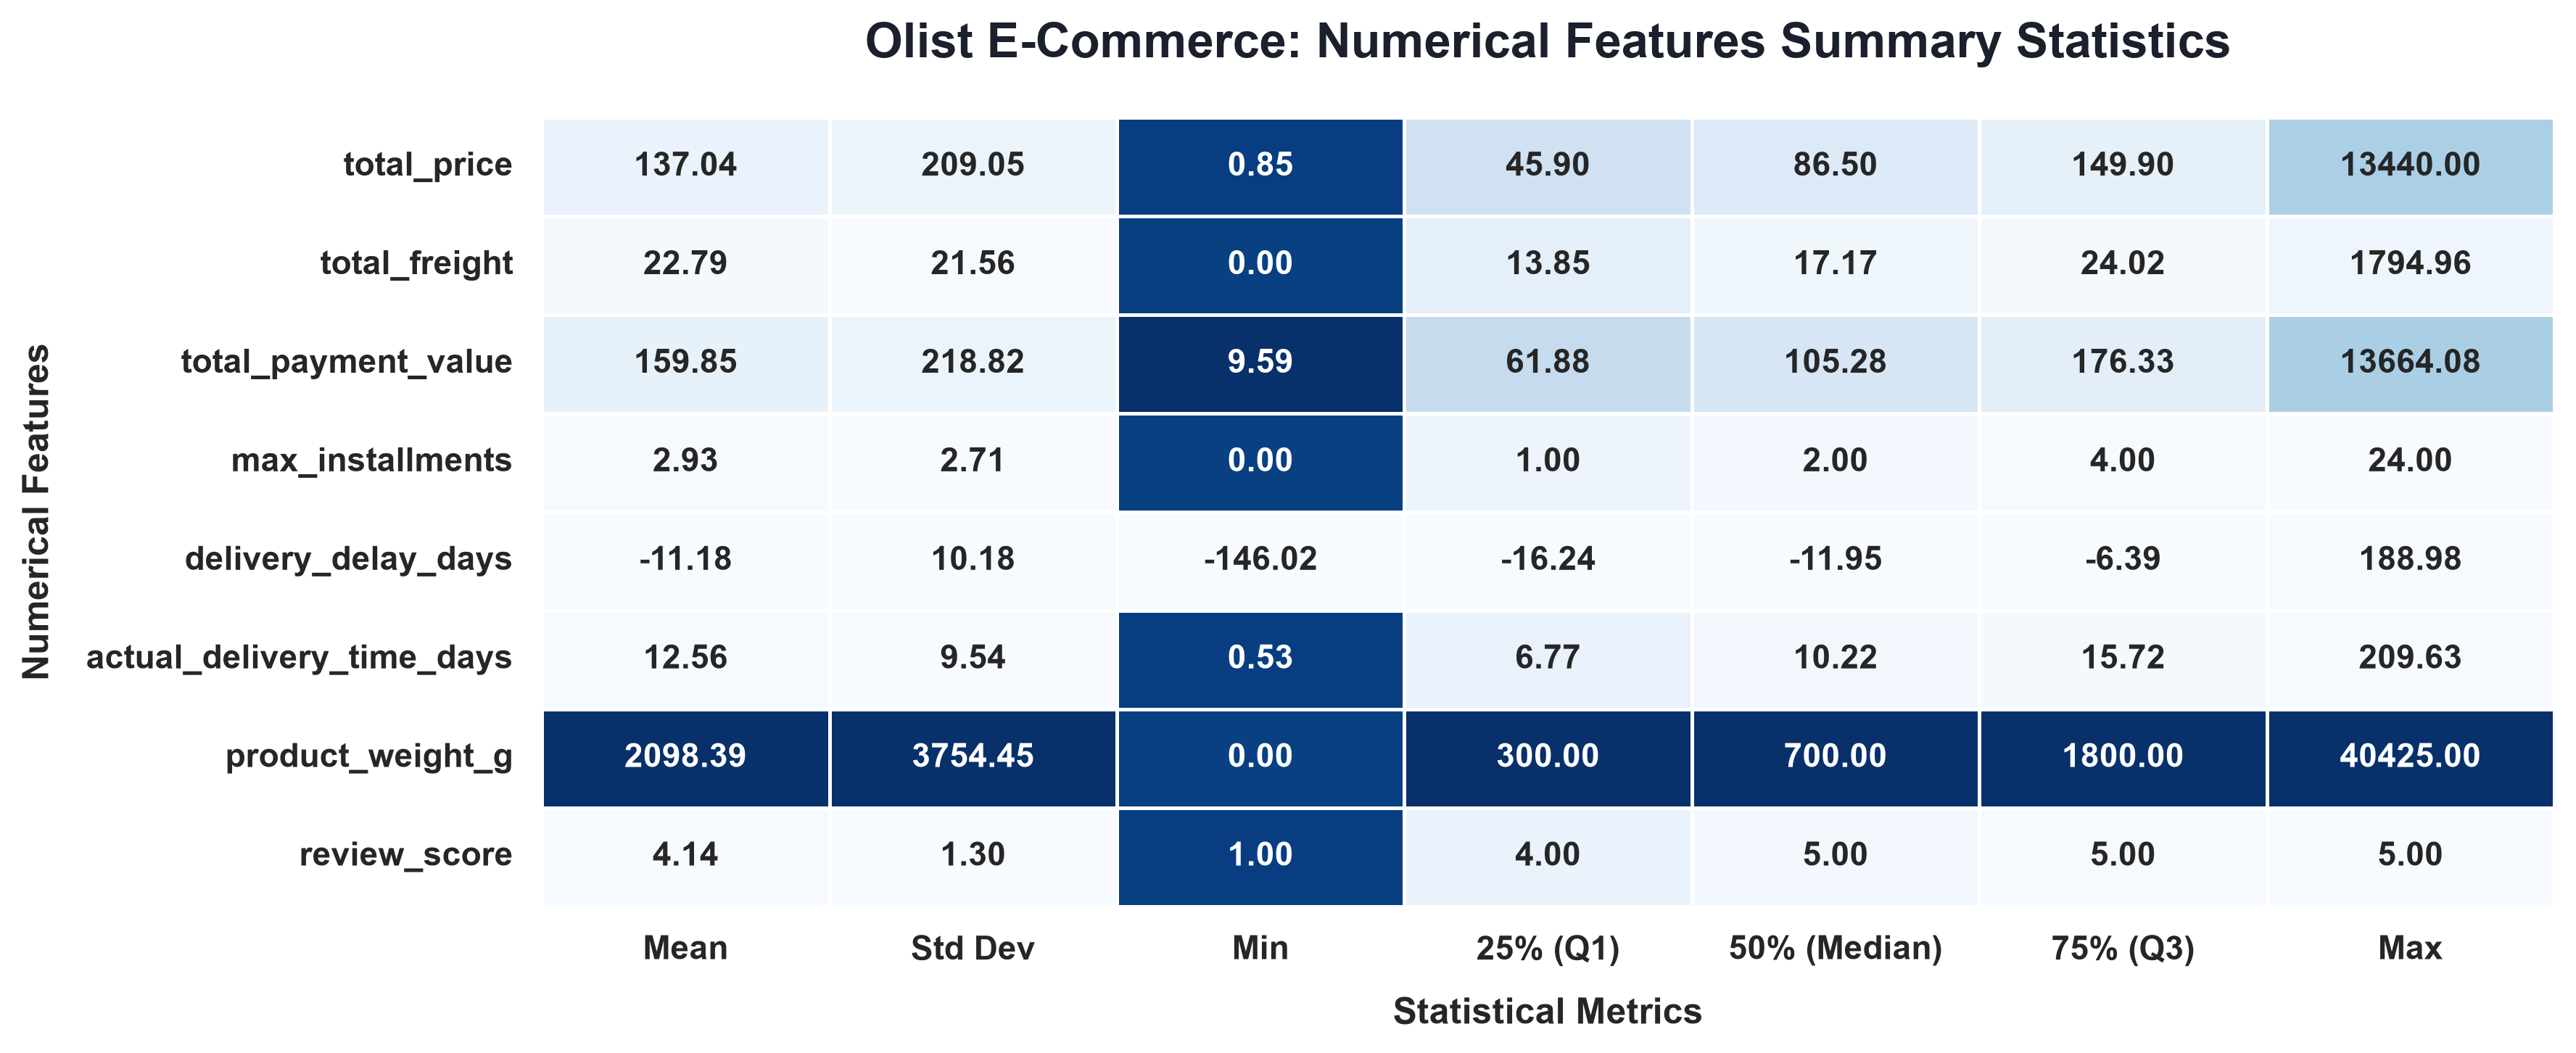

In [ ]:
# Select key continuous numerical columns for descriptive analysis
numeric_cols = [
    'total_price',
    'total_freight',
    'total_payment_value',
    'max_installments',
    'delivery_delay_days',
    'actual_delivery_time_days',
    'product_weight_g',
    'review_score',
]

# Calculate summary statistics
desc_stats = df[numeric_cols].describe().T[
    ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
]

# Standardize values (Min-Max Scaling) ONLY for heatmap coloring background
desc_scaled = (desc_stats - desc_stats.min(axis=0)) / (
    desc_stats.max(axis=0) - desc_stats.min(axis=0)
)

# Setup HD Figure Layout
plt.figure(figsize=(12, 5), dpi=300)
ax = sns.heatmap(
    desc_scaled,
    annot=desc_stats.values,  # Display actual real data numbers inside cells
    fmt='.2f',  # Round to 2 decimal places
    cmap='Blues',  # Crisp Olist Blue gradient
    linewidths=1.2,
    linecolor='white',
    cbar=False,  # Colorbar hidden as real numbers are annotated
    annot_kws={'size': 11, 'weight': 'bold'},
)

# Visual Polish
plt.title(
    'Olist E-Commerce: Numerical Features Summary Statistics',
    fontsize=16,
    weight='bold',
    pad=20,
    color='#1A202C',
)
plt.xlabel('Statistical Metrics', fontsize=12, weight='bold', labelpad=10)
plt.ylabel('Numerical Features', fontsize=12, weight='bold', labelpad=10)
plt.xticks(
    ticks=np.arange(7) + 0.5,
    labels=['Mean', 'Std Dev', 'Min', '25% (Q1)', '50% (Median)', '75% (Q3)', 'Max'],
    fontsize=11,
    weight='bold',
)
plt.yticks(rotation=0, fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

# Hackathon Requirments

## Core Q1: Olist Marketplace Scaling vs Customer Satisfaction Trend

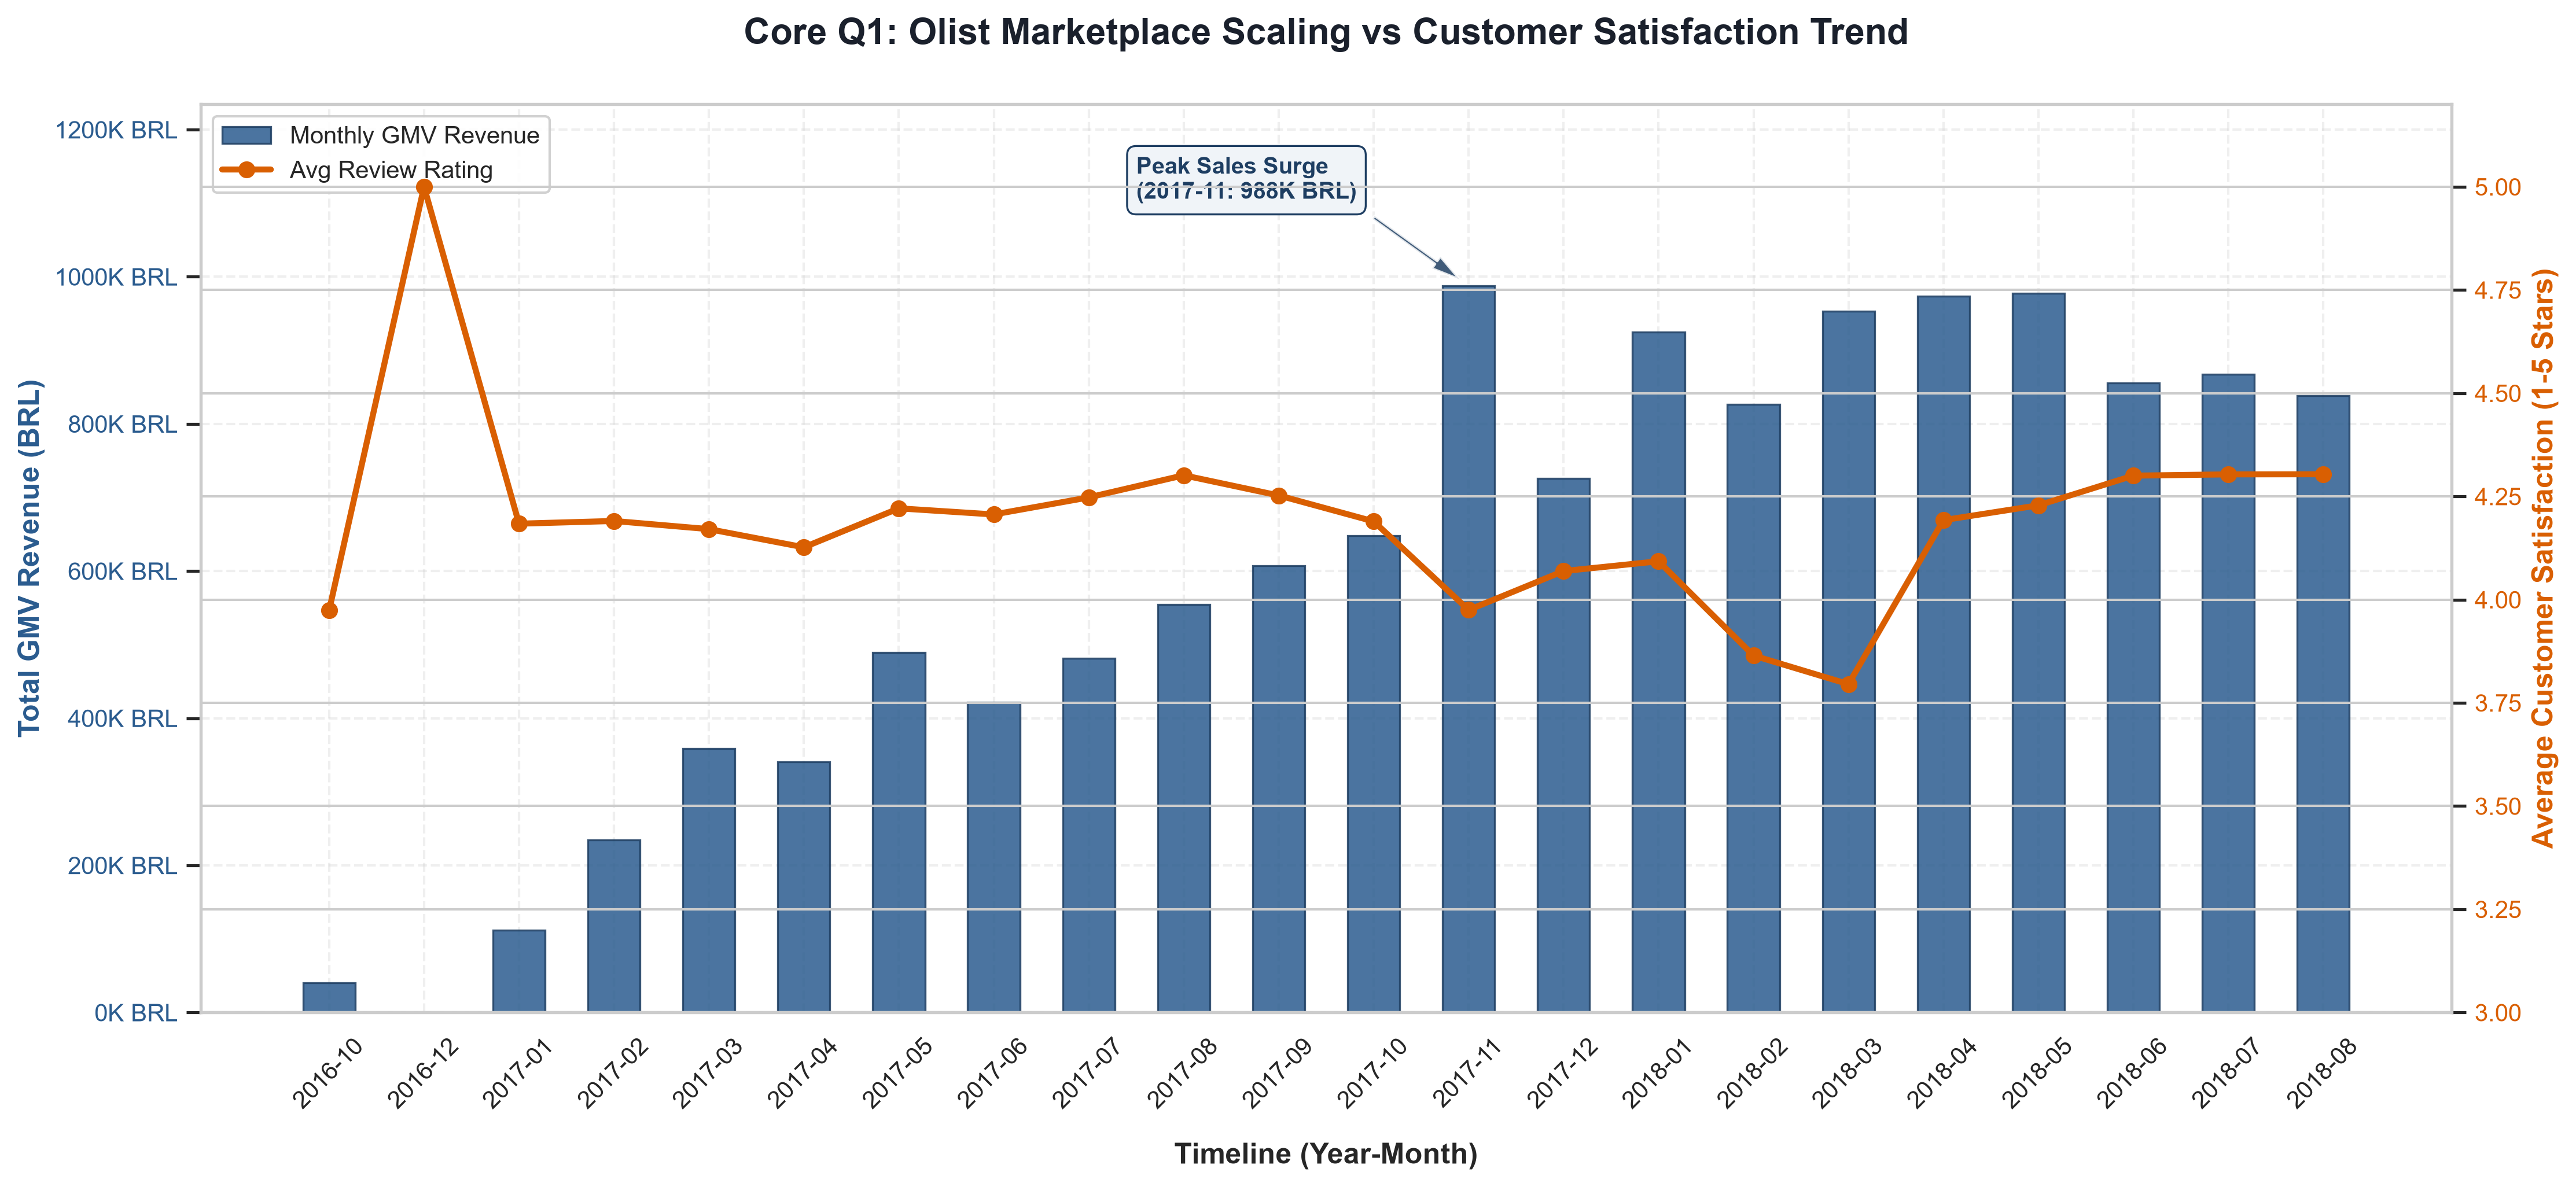

In [9]:
# Aggregate monthly metrics
monthly_df = (
    df.groupby('year_month')
    .agg(
        total_revenue=('total_price', 'sum'),
        total_orders=('order_id', 'count'),
        avg_rating=('review_score', 'mean'),
    )
    .reset_index()
)

monthly_df['year_month_str'] = monthly_df['year_month'].astype(str)

# High-Res Canvas
fig, ax1 = plt.subplots(figsize=(15, 7), dpi=300)

# Primary Axis: Revenue Bars
color_rev = '#2B5C8F'
ax1.set_xlabel('Timeline (Year-Month)', fontsize=12, weight='bold', labelpad=12)
ax1.set_ylabel(
    'Total GMV Revenue (BRL)', fontsize=12, weight='bold', color=color_rev
)

bars = ax1.bar(
    monthly_df['year_month_str'],
    monthly_df['total_revenue'],
    color=color_rev,
    alpha=0.85,
    width=0.55,
    edgecolor='#1E3E62',
    linewidth=0.8,
    label='Monthly GMV Revenue',
)

ax1.tick_params(axis='y', labelcolor=color_rev, labelsize=10)
ax1.tick_params(axis='x', rotation=45, labelsize=10)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, loc: f'{int(x/1e3)}K BRL')
)

# Secondary Axis: Review Score Line
ax2 = ax1.twinx()
color_rate = '#D95F02'
ax2.set_ylabel(
    'Average Customer Satisfaction (1-5 Stars)',
    fontsize=12,
    weight='bold',
    color=color_rate,
)

line = ax2.plot(
    monthly_df['year_month_str'],
    monthly_df['avg_rating'],
    color=color_rate,
    marker='o',
    markersize=6,
    linewidth=2.5,
    label='Avg Review Rating',
)

ax2.tick_params(axis='y', labelcolor=color_rate, labelsize=10)

# Expanded Y-limits to prevent line clipping
ax2.set_ylim(3.0, 5.2)
ax1.set_ylim(0, monthly_df['total_revenue'].max() * 1.25)

# Fixed Annotation (Positioned cleanly inside graph area)
max_rev_idx = monthly_df['total_revenue'].idxmax()
max_month = monthly_df.loc[max_rev_idx, 'year_month_str']
max_rev_val = monthly_df.loc[max_rev_idx, 'total_revenue']

ax1.annotate(
    f'Peak Sales Surge\n({max_month}: {max_rev_val/1e3:.0f}K BRL)',
    xy=(max_rev_idx, max_rev_val),
    xytext=(max_rev_idx - 3.5, max_rev_val * 1.12),
    arrowprops=dict(
        facecolor='#1E3E62', shrink=0.08, width=1.5, headwidth=6, alpha=0.85
    ),
    fontsize=9.5,
    weight='bold',
    color='#1E3E62',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#F0F4F8',
        edgecolor='#1E3E62',
        linewidth=0.8,
    ),
)

# Legend Layout
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc='upper left',
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    fontsize=10,
)

# Clean Title Placement
plt.title(
    'Core Q1: Olist Marketplace Scaling vs Customer Satisfaction Trend',
    fontsize=15,
    weight='bold',
    pad=25,
    color='#1A202C',
)
ax1.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Business Insights (Core Q1: Scaling vs. Customer Satisfaction)

* **Rapid GMV Growth Trajectory:** Olist demonstrated strong revenue growth, increasing from relatively low baseline figures in late 2016 to maintaining a stable monthly revenue range of approximately **800K–1.0M BRL** throughout 2018.

* **Black Friday Operational Stress (November 2017):** Revenue reached an all-time high of approximately **988K BRL** in November 2017. However, the sudden demand surge created significant logistics bottlenecks, causing the average customer review score to decline sharply to around **4.0 stars**.

* **Logistics Bottleneck Residual Impact (Q1 2018):** The operational strain caused by the November holiday surge continued into early 2018. Customer satisfaction reached its lowest level in **March 2018**, falling to approximately **3.7 stars**, largely due to accumulated delivery delays.

* **Service Quality Recovery (Mid-2018):** Following operational improvements, service quality recovered significantly. Average customer ratings stabilized at approximately **4.25 stars**, while monthly GMV remained strong at **800K+ BRL**, demonstrating that Olist was able to sustain high sales volume without sacrificing customer satisfaction.


## Core Q2: Quantifying Logistics Delays Impact on Customer Churn & Dissatisfaction

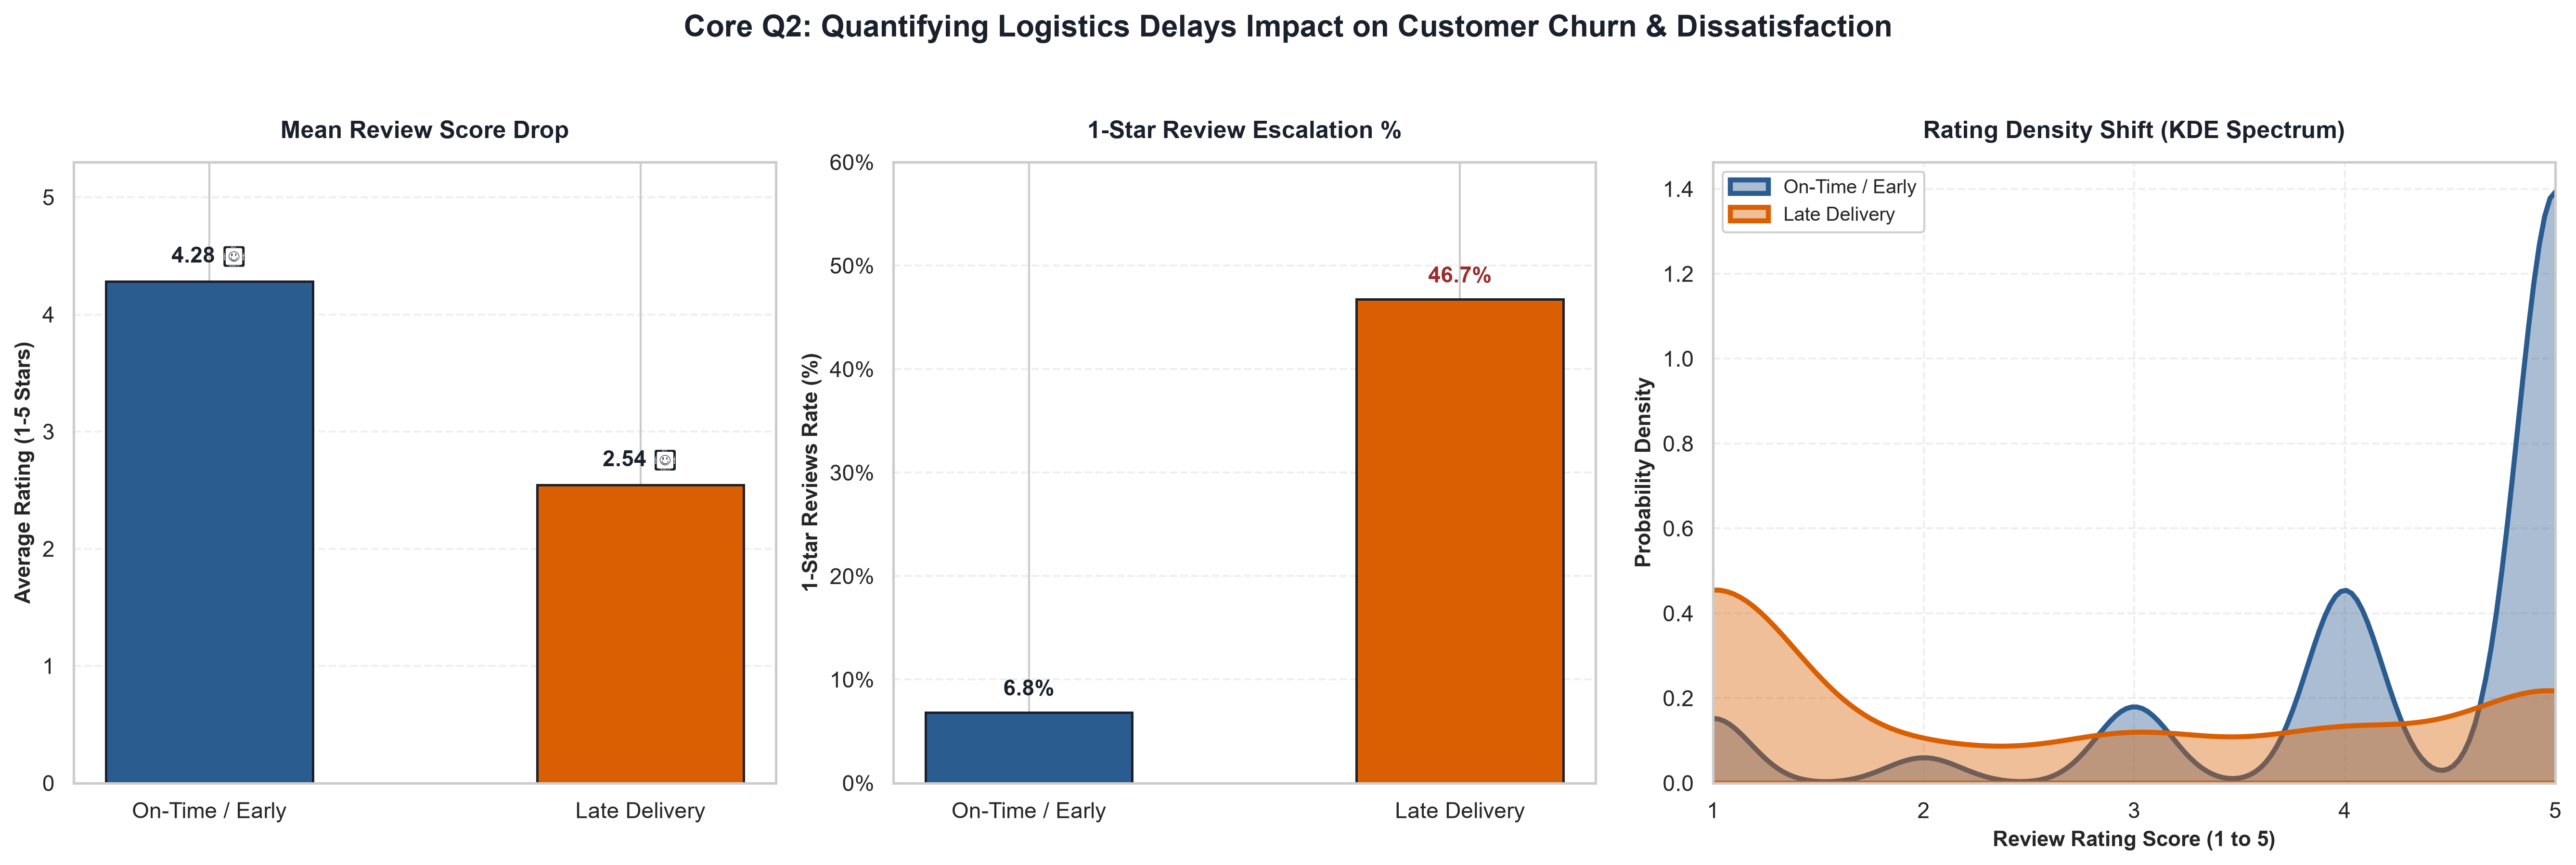

In [10]:
# 1. Aggregate Core Metrics
stats = (
    df.groupby('is_late')
    .agg(
        avg_rating=('review_score', 'mean'),
        one_star_pct=('review_score', lambda x: (x == 1).mean() * 100),
        total_orders=('order_id', 'count'),
    )
    .reset_index()
)
stats['status'] = stats['is_late'].map(
    {0: 'On-Time / Early', 1: 'Late Delivery'}
)

# 2. Setup 3-Panel High-Impact Layout
fig = plt.figure(figsize=(18, 5.8), dpi=300)
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.2])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Panel 1: Average Rating Comparison
colors = ['#2B5C8F', '#D95F02']
bars1 = ax1.bar(
    stats['status'],
    stats['avg_rating'],
    color=colors,
    width=0.48,
    edgecolor='#1A202C',
    linewidth=1.2,
)
ax1.set_title(
    'Mean Review Score Drop', fontsize=12, weight='bold', pad=12, color='#1A202C'
)
ax1.set_ylabel('Average Rating (1-5 Stars)', fontsize=10.5, weight='bold')
ax1.set_ylim(0, 5.3)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.12,
        f'{yval:.2f} ★',
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold',
        color='#1A202C',
    )

# Panel 2: 1-Star Review Escalation Rate
bars2 = ax2.bar(
    stats['status'],
    stats['one_star_pct'],
    color=colors,
    width=0.48,
    edgecolor='#1A202C',
    linewidth=1.2,
)
ax2.set_title(
    '1-Star Review Escalation %',
    fontsize=12,
    weight='bold',
    pad=12,
    color='#1A202C',
)
ax2.set_ylabel('1-Star Reviews Rate (%)', fontsize=10.5, weight='bold')
ax2.set_ylim(0, 60)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter())
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 1.2,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold',
        color='#9B2C2C' if yval > 20 else '#1A202C',
    )

# Panel 3: Full Rating Density Curve (Seaborn Distribution)
sns.kdeplot(
    data=df[df['is_late'] == 0]['review_score'],
    ax=ax3,
    color='#2B5C8F',
    fill=True,
    alpha=0.4,
    linewidth=2.5,
    label='On-Time / Early',
    bw_adjust=1.5,
)
sns.kdeplot(
    data=df[df['is_late'] == 1]['review_score'],
    ax=ax3,
    color='#D95F02',
    fill=True,
    alpha=0.4,
    linewidth=2.5,
    label='Late Delivery',
    bw_adjust=1.5,
)

ax3.set_title(
    'Rating Density Shift (KDE Spectrum)',
    fontsize=12,
    weight='bold',
    pad=12,
    color='#1A202C',
)
ax3.set_xlabel('Review Rating Score (1 to 5)', fontsize=10.5, weight='bold')
ax3.set_ylabel('Probability Density', fontsize=10.5, weight='bold')
ax3.set_xlim(1, 5)
ax3.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax3.legend(frameon=True, facecolor='white', framealpha=0.9, fontsize=9.5)
ax3.grid(True, linestyle='--', alpha=0.3)

# Master Title
plt.suptitle(
    'Core Q2: Quantifying Logistics Delays Impact on Customer Churn & Dissatisfaction',
    fontsize=15,
    weight='bold',
    y=1.03,
    color='#1A202C',
)

plt.tight_layout()
plt.show()

### Key Business Insights (Core Q2: Quantifying Logistics Delays Impact)

 * Severe Rating Collapse: On-time aur early deliveries par average customer satisfaction 4.28 Stars hai, lekin delivery date breach hote hi score plummet hokar 2.54 Stars par aa jata hai (a massive ~40.6% rating penalty).

 * 7x Surge in 1-Star Review Escalation: On-time orders par sirf 6.8% customers 1-Star review dete hain, jabke late deliveries ke case mein 1-Star review rate exponential surge hokar 46.7% tak pahunch jata hai (~7x increase).

 * Bimodal Density Inversion (KDE Spectrum): Rating density curve clearly dikhati hai ke on-time deliveries ka distribution 5-Star peak par heavily concentrated hai, jabke late deliveries par distribution complete flip hokar 1-Star peak par shift ho jata hai.

 * Core Takeaway: Logistics fulfillment speed hi marketplace par retention aur customer churn ka single biggest deciding factor hai.

## Core Q3: Geographic Logistics Bottlenecks & Demand Concentration

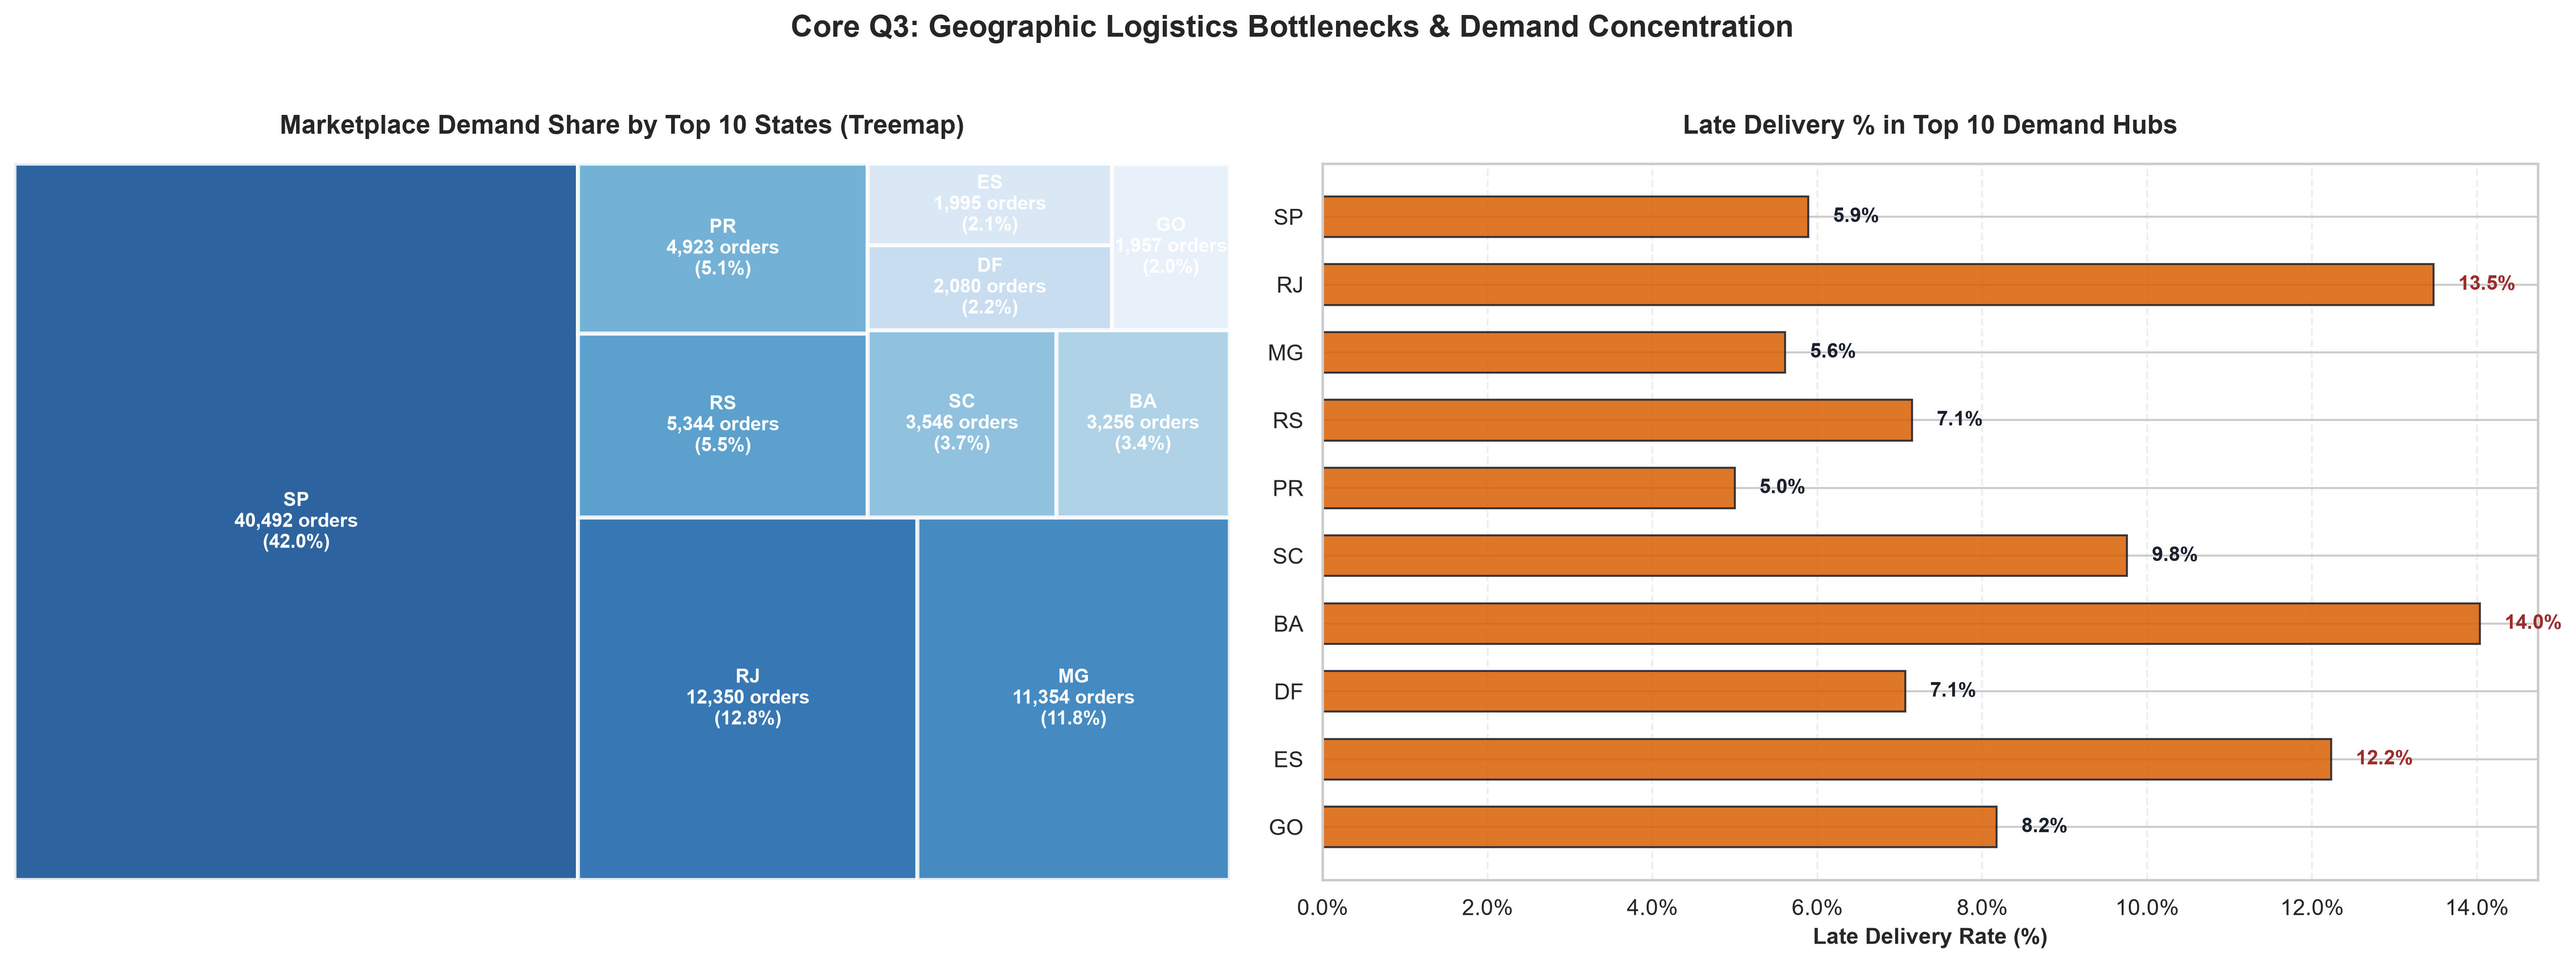

In [11]:
# 1. Aggregate State-level performance metrics
state_df = (
    df.groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('total_price', 'sum'),
        avg_freight=('total_freight', 'mean'),
        avg_delay=('delivery_delay_days', 'mean'),
        late_pct=('is_late', lambda x: x.mean() * 100),
        avg_rating=('review_score', 'mean'),
    )
    .reset_index()
    .sort_values(by='total_orders', ascending=False)
)

# Top 10 States for detail breakdown
top10_states = state_df.head(10)

# 2. Setup 2-Panel Layout (Treemap + Late Rate Bar Chart)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6.5), dpi=300)

# Panel 1: Treemap of Order Volume Share by Top States
colors_treemap = sns.color_palette('Blues_r', n_colors=len(top10_states))
labels = [
    f'{row["customer_state"]}\n{row["total_orders"]:,} orders\n({row["total_orders"]/len(df)*100:.1f}%)'
    for _, row in top10_states.iterrows()
]

squarify.plot(
    sizes=top10_states['total_orders'],
    label=labels,
    color=colors_treemap,
    alpha=0.85,
    ax=ax1,
    text_kwargs={'fontsize': 9.5, 'weight': 'bold', 'color': 'white'},
    bar_kwargs={'edgecolor': 'white', 'linewidth': 2},
)
ax1.set_title(
    'Marketplace Demand Share by Top 10 States (Treemap)',
    fontsize=13,
    weight='bold',
    pad=15,
)
ax1.axis('off')

# Panel 2: Late Delivery Percentage by Top States
bars = ax2.barh(
    top10_states['customer_state'][::-1],
    top10_states['late_pct'][::-1],
    color='#D95F02',
    alpha=0.85,
    height=0.6,
    edgecolor='#1A202C',
)

ax2.set_title(
    'Late Delivery % in Top 10 Demand Hubs', fontsize=13, weight='bold', pad=15
)
ax2.set_xlabel('Late Delivery Rate (%)', fontsize=11, weight='bold')
ax2.xaxis.set_major_formatter(ticker.PercentFormatter())
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

for bar in bars:
    xval = bar.get_width()
    ax2.text(
        xval + 0.3,
        bar.get_y() + bar.get_height() / 2.0,
        f'{xval:.1f}%',
        ha='left',
        va='center',
        fontsize=10,
        weight='bold',
        color='#9B2C2C' if xval > 10 else '#1A202C',
    )

# Master Title
plt.suptitle(
    'Core Q3: Geographic Logistics Bottlenecks & Demand Concentration',
    fontsize=15,
    weight='bold',
    y=1.02,
)

plt.tight_layout()
plt.show()

### Key Business Insights (Core Q3: Geographic Bottlenecks & Demand Share)

* **Heavy Demand Concentration (SP Dominance):** São Paulo (SP) is the primary engine of the marketplace, accounting for **42.0% of total order volume (40,492 orders)**. The top three states — **SP, RJ, and MG** — collectively represent approximately **66.6% of total demand**.

* **Rio de Janeiro Operational Risk:** Despite being the **second-largest state by demand (12.8% of total volume)**, Rio de Janeiro has an alarming **13.5% late delivery rate**, which is more than **twice the rate observed in São Paulo (5.9%)**.

* **Regional Logistics Friction:** Outer states such as **Bahia (BA: 14.0%)** and **Espírito Santo (ES: 12.2%)** experience some of the most severe fulfillment delays. This indicates potential challenges associated with **cross-state shipping routes and regional carrier inefficiencies**.


## Core Q4: Category Performance Triad — Volume, Revenue & Satisfaction Dynamics

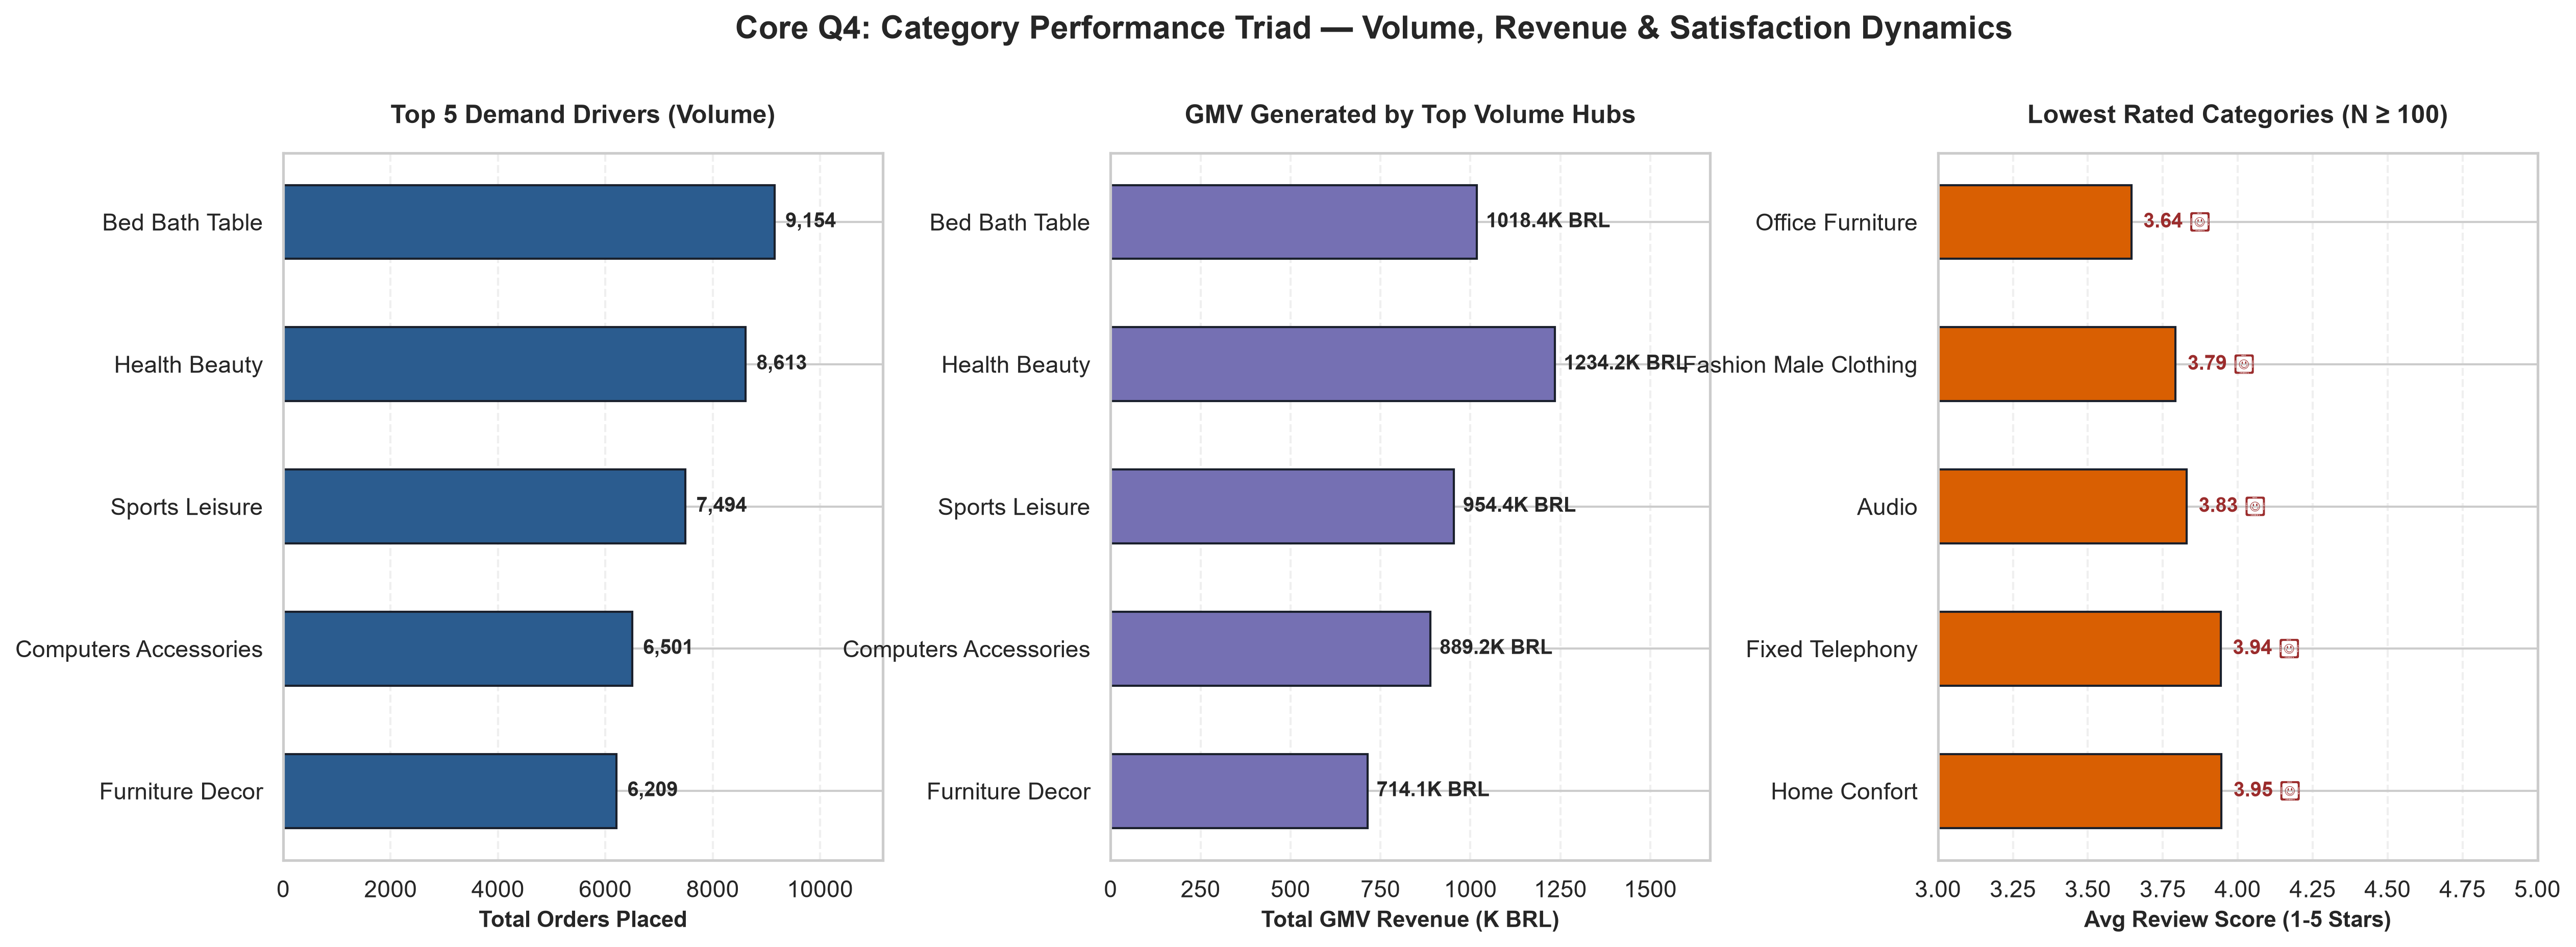

In [12]:
# 1. Prepare Data
cat_df = (
    df.groupby('product_category_name_english')
    .agg(
        total_orders=('order_id', 'count'),
        total_revenue=('total_price', 'sum'),
        avg_rating=('review_score', 'mean'),
    )
    .reset_index()
)

cat_df['category_clean'] = (
    cat_df['product_category_name_english'].str.replace('_', ' ').str.title()
)

top5_volume = cat_df.sort_values(by='total_orders', ascending=False).head(5)
bottom5_rating = (
    cat_df[cat_df['total_orders'] >= 100]
    .sort_values(by='avg_rating', ascending=True)
    .head(5)
)

# 2. Setup 3-Panel Fixed Canvas Spacing
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(19, 6), dpi=300, gridspec_kw={'wspace': 0.38}
)

# Panel 1: Top Volume Categories
bars1 = ax1.barh(
    top5_volume['category_clean'][::-1],
    top5_volume['total_orders'][::-1],
    color='#2B5C8F',
    edgecolor='#1A202C',
    height=0.52,
)
ax1.set_title(
    'Top 5 Demand Drivers (Volume)', fontsize=12, weight='bold', pad=14
)
ax1.set_xlabel('Total Orders Placed', fontsize=10.5, weight='bold')
ax1.set_xlim(0, max(top5_volume['total_orders']) * 1.22)
ax1.grid(True, linestyle='--', alpha=0.3, axis='x')

for bar in bars1:
    xval = bar.get_width()
    ax1.text(
        xval + 200,
        bar.get_y() + bar.get_height() / 2.0,
        f'{xval:,}',
        ha='left',
        va='center',
        fontsize=9.5,
        weight='bold',
    )

# Panel 2: Total GMV Revenue
bars2 = ax2.barh(
    top5_volume['category_clean'][::-1],
    (top5_volume['total_revenue'] / 1e3)[::-1],
    color='#7570B3',
    edgecolor='#1A202C',
    height=0.52,
)
ax2.set_title(
    'GMV Generated by Top Volume Hubs', fontsize=12, weight='bold', pad=14
)
ax2.set_xlabel('Total GMV Revenue (K BRL)', fontsize=10.5, weight='bold')
# Extended X-Limit to eliminate label truncation/overlap
ax2.set_xlim(0, max(top5_volume['total_revenue'] / 1e3) * 1.35)
ax2.grid(True, linestyle='--', alpha=0.3, axis='x')

for bar in bars2:
    xval = bar.get_width()
    ax2.text(
        xval + 25,
        bar.get_y() + bar.get_height() / 2.0,
        f'{xval:.1f}K BRL',
        ha='left',
        va='center',
        fontsize=9.5,
        weight='bold',
    )

# Panel 3: Worst Rated Categories
bars3 = ax3.barh(
    bottom5_rating['category_clean'][::-1],
    bottom5_rating['avg_rating'][::-1],
    color='#D95F02',
    edgecolor='#1A202C',
    height=0.52,
)
ax3.set_title(
    'Lowest Rated Categories (N ≥ 100)', fontsize=12, weight='bold', pad=14
)
ax3.set_xlabel('Avg Review Score (1-5 Stars)', fontsize=10.5, weight='bold')
ax3.set_xlim(3.0, 5.0)
ax3.grid(True, linestyle='--', alpha=0.3, axis='x')

for bar in bars3:
    xval = bar.get_width()
    ax3.text(
        xval + 0.04,
        bar.get_y() + bar.get_height() / 2.0,
        f'{xval:.2f} ★',
        ha='left',
        va='center',
        fontsize=9.5,
        weight='bold',
        color='#9B2C2C',
    )

# Master Title
plt.suptitle(
    'Core Q4: Category Performance Triad — Volume, Revenue & Satisfaction Dynamics',
    fontsize=15,
    weight='bold',
    y=1.03,
)

# Tight layout with generous rect limits to avoid margin cutting
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Key Business Insights (Core Q4: Category Performance Spectrum)

* **Category Volume Heavyweights:** **Bed Bath Table (9,154 orders)** and **Health Beauty (8,613 orders)** are the primary demand-driving categories in the marketplace, making them critical for initial customer acquisition and market growth.

* **High-Ticket GMV Drivers:** **Health Beauty** leads total GMV revenue with approximately **1.23M BRL**, reflecting a higher average order value (AOV) and outperforming **Bed Bath Table (~1.02M BRL)** in overall revenue contribution.

* **Quality & Fulfillment Bottlenecks:** Customer satisfaction is lowest for bulky and assembly-intensive product categories. **Office Furniture** is the lowest-rated major category at **3.64 stars**, followed by **Fashion Male Clothing (3.79 stars)**, highlighting potential issues related to product sizing, transportation handling, and delivery logistics.


## Core Q5: Payment Dynamics — Consumer Financing & Transaction Preferences

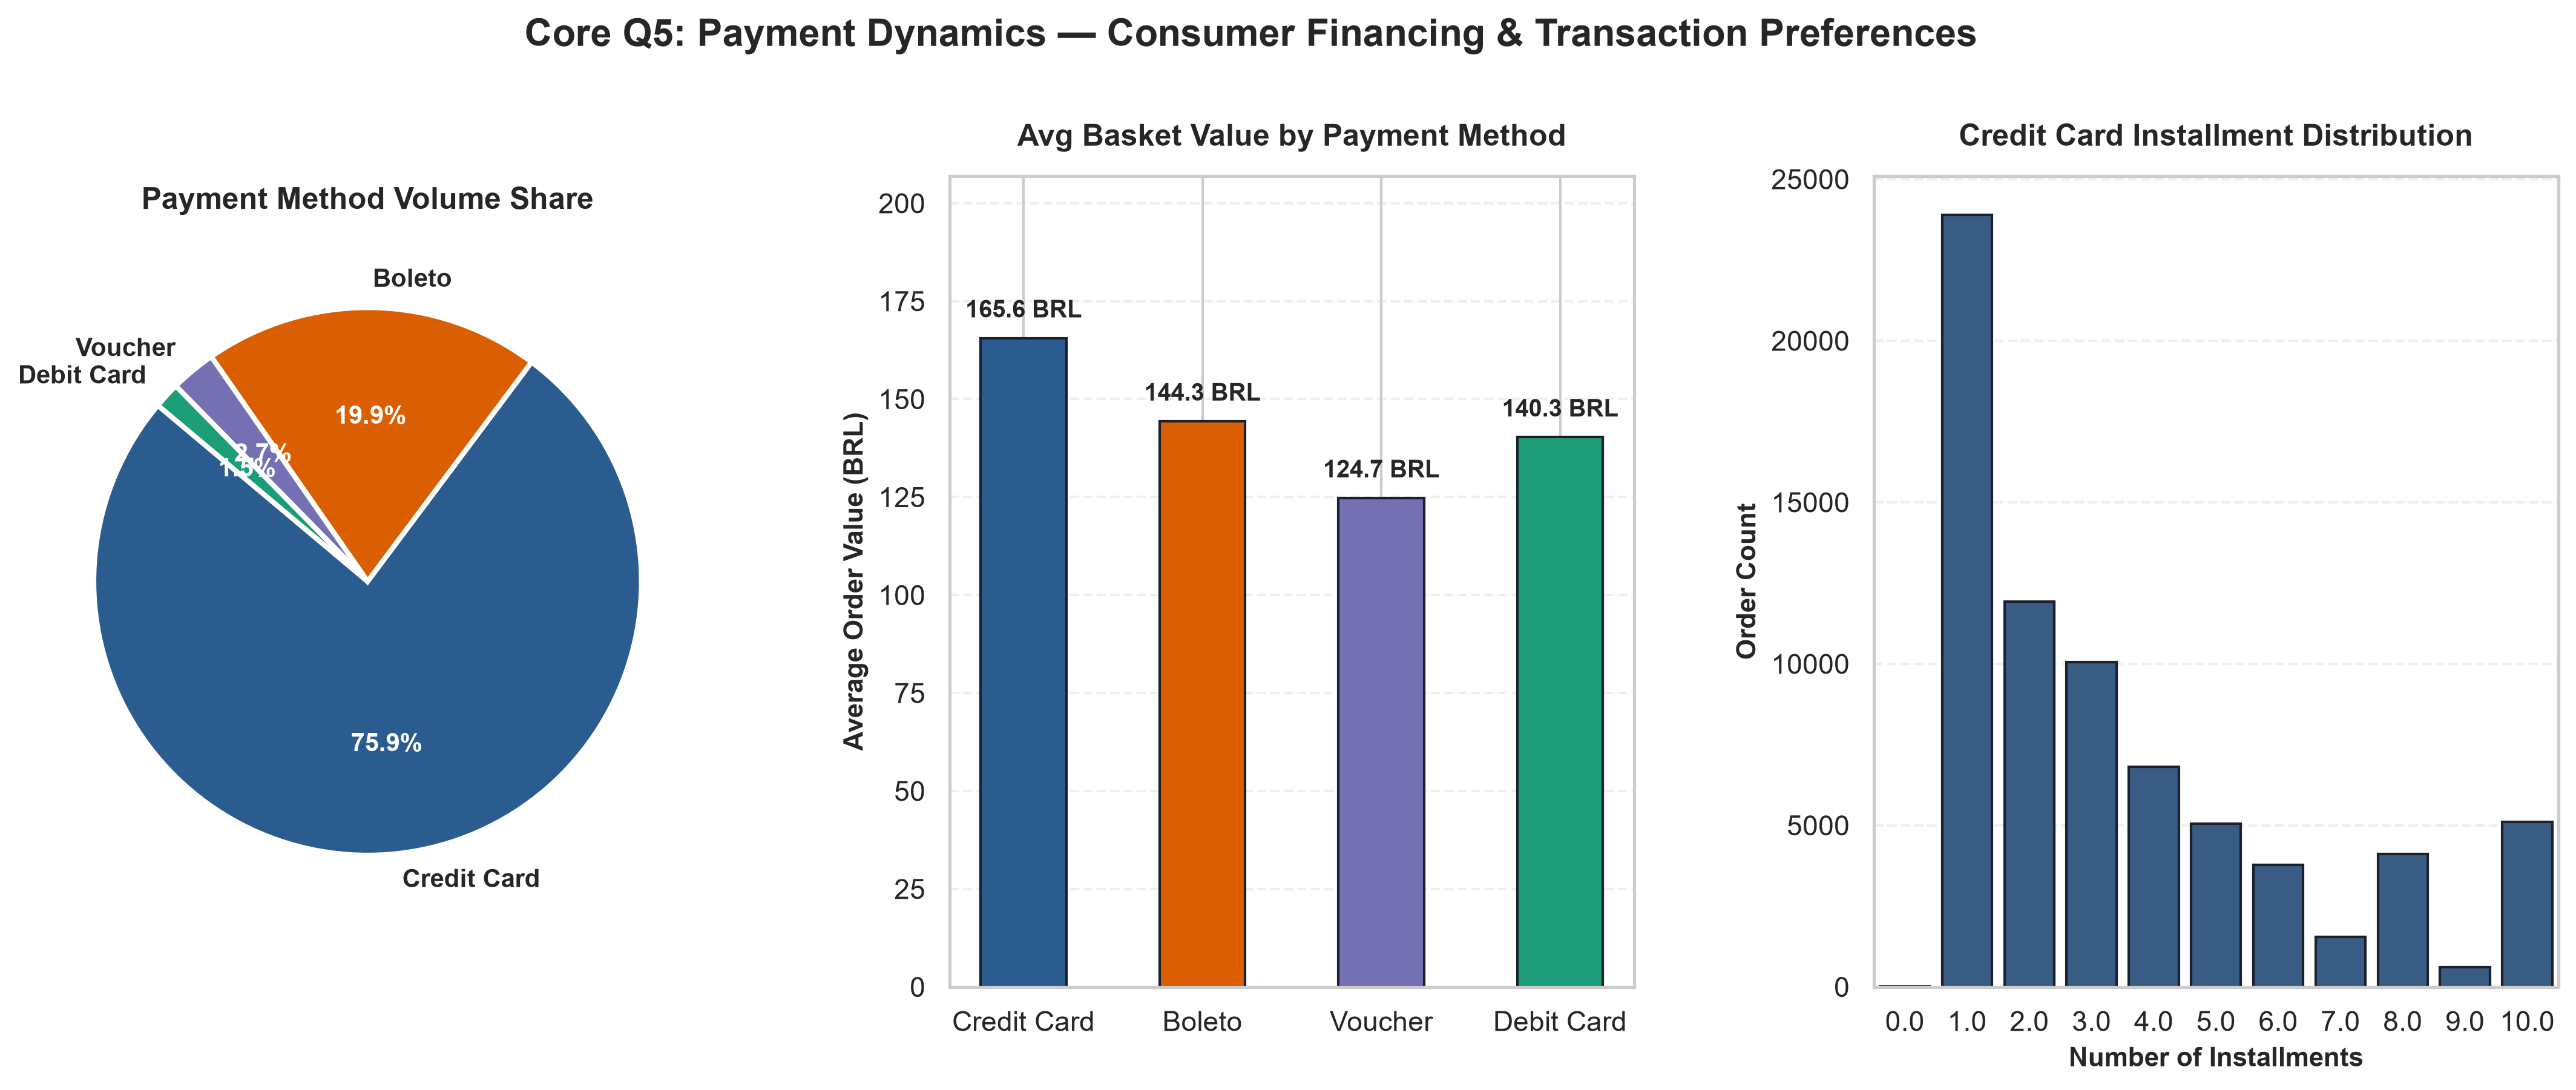

In [13]:
# 1. Aggregate Payment Metrics using exact column names
pm_df = (
    df.groupby('primary_payment_type')
    .agg(
        total_orders=('order_id', 'count'),
        total_value=('total_payment_value', 'sum'),
        avg_installments=('max_installments', 'mean'),
        avg_value=('total_payment_value', 'mean'),
    )
    .reset_index()
    .sort_values(by='total_orders', ascending=False)
)

# Clean labels & filter out invalid values
pm_df['type_clean'] = (
    pm_df['primary_payment_type'].astype(str).str.replace('_', ' ').str.title()
)
pm_df = pm_df[~pm_df['primary_payment_type'].isin(['not_defined', '0', 0, np.nan])]

# 2. Setup 3-Panel Executive Visualization
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(18, 5.8), dpi=300, gridspec_kw={'wspace': 0.35}
)

# Panel 1: Payment Method Volume Share
colors_pm = ['#2B5C8F', '#D95F02', '#7570B3', '#1B9E77']
wedges, texts, autotexts = ax1.pie(
    pm_df['total_orders'],
    labels=pm_df['type_clean'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_pm[: len(pm_df)],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10, 'weight': 'bold'},
)
for autotext in autotexts:
    autotext.set_color('white')
ax1.set_title(
    'Payment Method Volume Share', fontsize=12, weight='bold', pad=12
)

# Panel 2: Average Basket Value by Method
bars2 = ax2.bar(
    pm_df['type_clean'],
    pm_df['avg_value'],
    color=colors_pm[: len(pm_df)],
    width=0.48,
    edgecolor='#1A202C',
)
ax2.set_title(
    'Avg Basket Value by Payment Method', fontsize=12, weight='bold', pad=12
)
ax2.set_ylabel('Average Order Value (BRL)', fontsize=10.5, weight='bold')
ax2.set_ylim(0, max(pm_df['avg_value']) * 1.25)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 4,
        f'{yval:.1f} BRL',
        ha='center',
        va='bottom',
        fontsize=9.5,
        weight='bold',
    )

# Panel 3: Installments Distribution for Credit Card
credit_cc = df[df['primary_payment_type'] == 'credit_card']
sns.countplot(
    data=credit_cc,
    x='max_installments',
    ax=ax3,
    color='#2B5C8F',
    edgecolor='#1A202C',
)
ax3.set_title(
    'Credit Card Installment Distribution', fontsize=12, weight='bold', pad=12
)
ax3.set_xlabel('Number of Installments', fontsize=10.5, weight='bold')
ax3.set_ylabel('Order Count', fontsize=10.5, weight='bold')
ax3.set_xlim(-0.5, 10.5)
ax3.grid(True, linestyle='--', alpha=0.3, axis='y')

# Master Title
plt.suptitle(
    'Core Q5: Payment Dynamics — Consumer Financing & Transaction Preferences',
    fontsize=15,
    weight='bold',
    y=1.03,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Key Business Insights (Core Q5: Payment Dynamics & Financing Trends)

* **Credit Card Dominance:** Credit Cards account for approximately **75.9% of total order volume**, making them the primary transaction method on the platform. **Boleto** follows as the second-largest payment method, with a **19.9% share**.

* **Higher Basket Values Through Financing:** Credit Card transactions have the highest average basket value at approximately **165.6 BRL**, compared with **144.3 BRL** for Boleto and **140.3 BRL** for Debit Cards. This indicates that customers tend to make higher-value purchases when using Credit Card payments.

* **Installment Behavior & High-Ticket Spikes:** While the majority of customers prefer **1 installment (single payment)**, noticeable volume spikes occur at **2–4 installments** and **10 installments**. This highlights a significant customer preference for installment-based financing, particularly for higher-value purchases.

* **Core Takeaway:** **Credit Cards are the dominant payment channel and also drive higher-value transactions, while installment options play an important role in enabling larger purchases.**


## Core Q6: Logistics Speed & Delivery Delays Impact on Customer Satisfaction

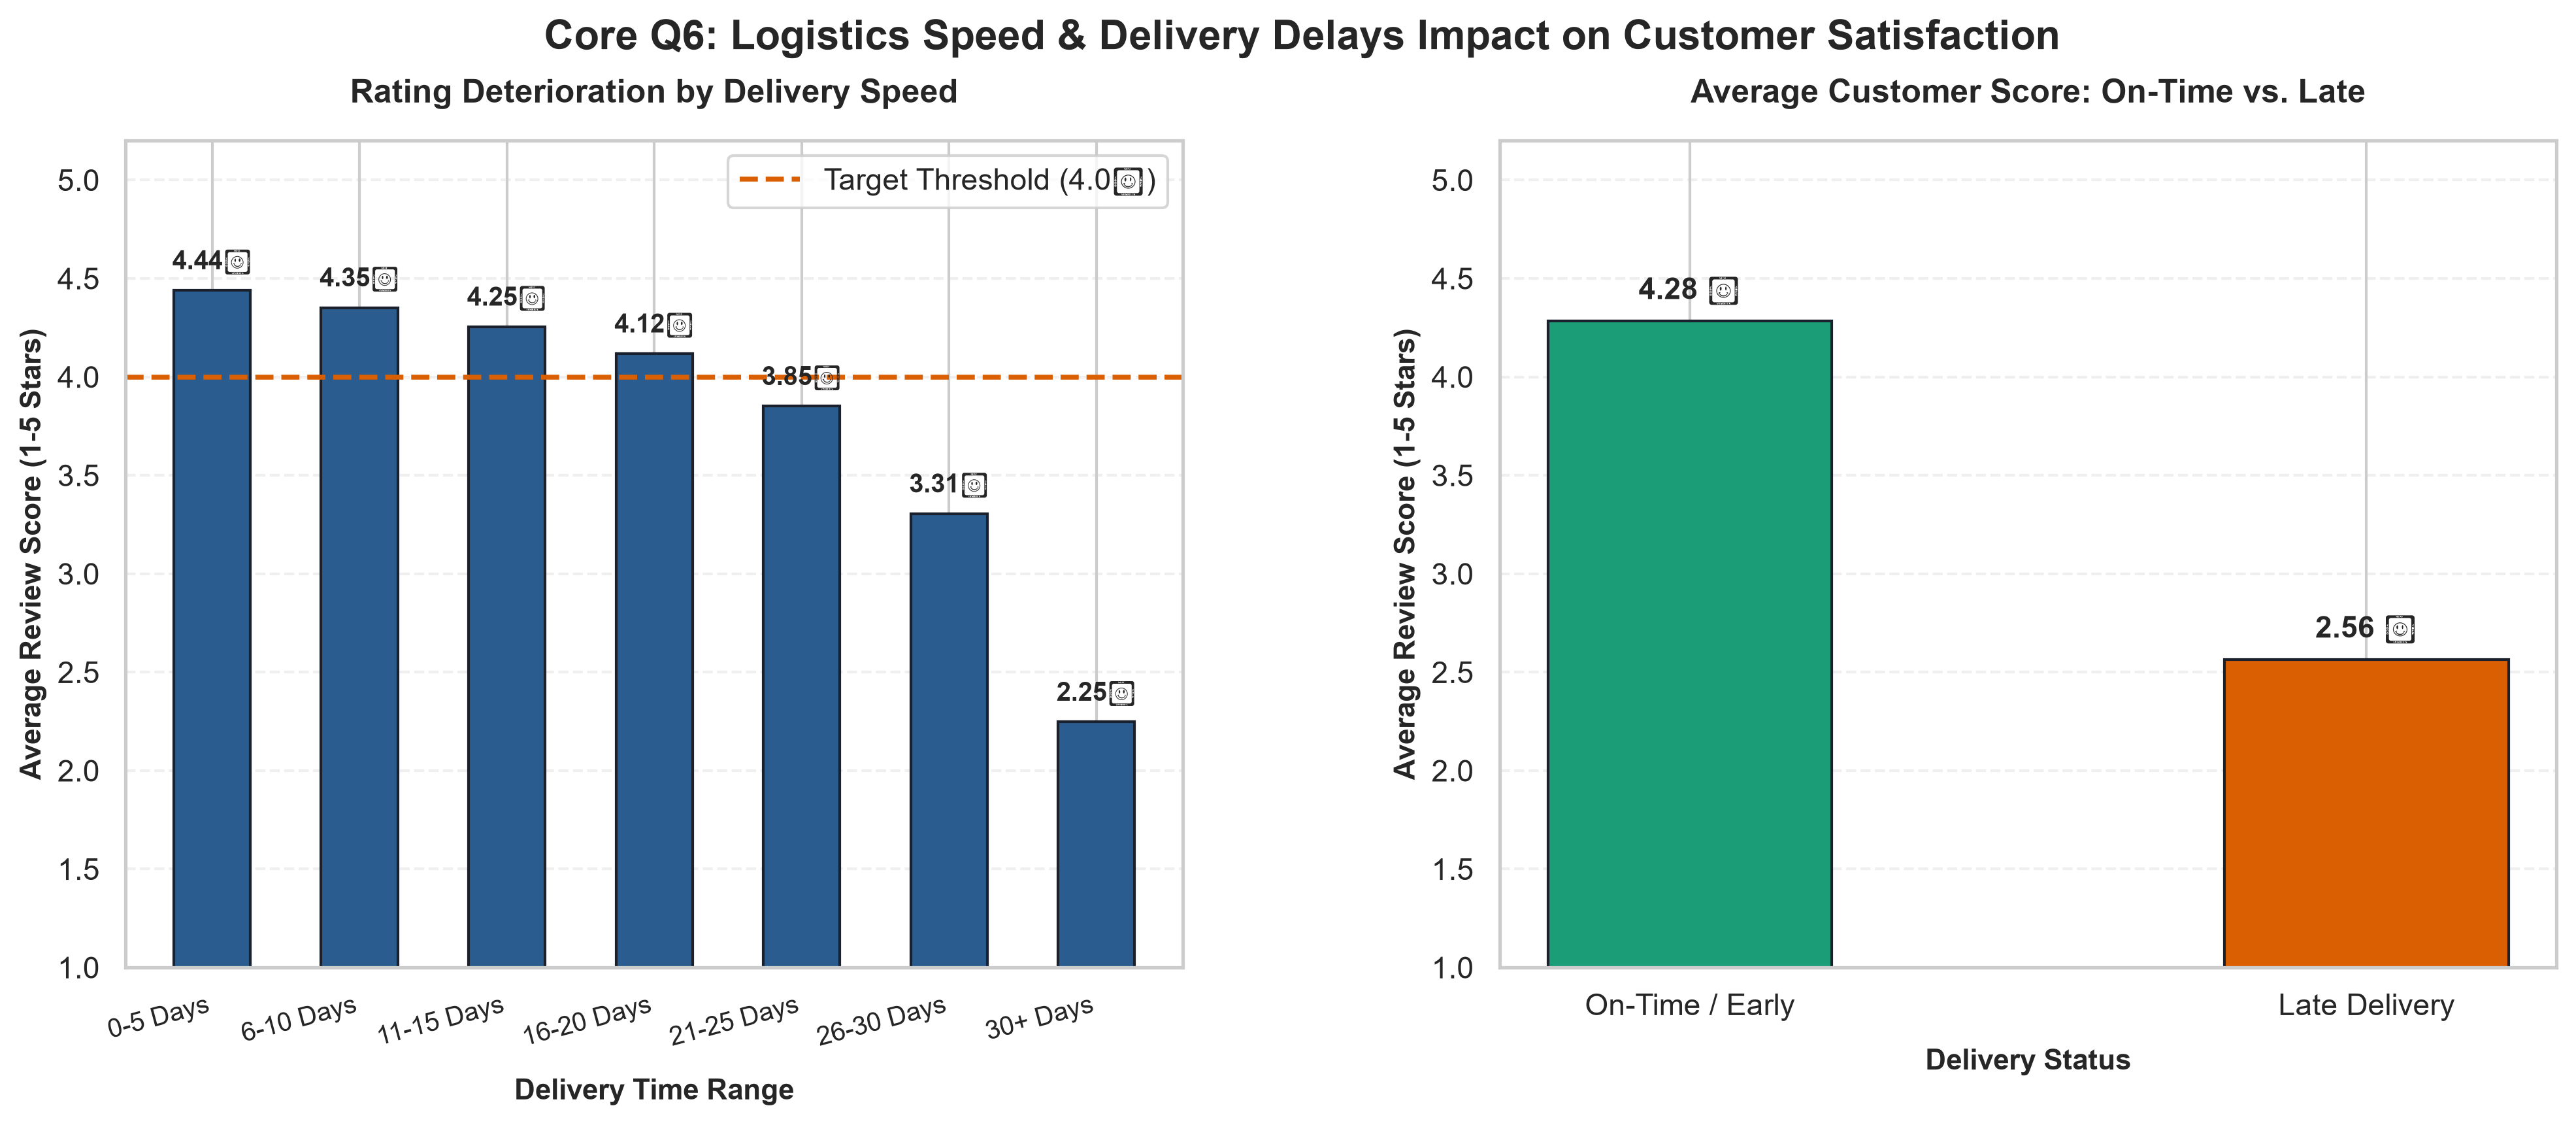

In [14]:
# 1. Clean Data & Binning Delivery Time
deliv_df = df.dropna(
    subset=['actual_delivery_time_days', 'review_score']
).copy()
deliv_df = deliv_df[
    (deliv_df['actual_delivery_time_days'] >= 0)
    & (deliv_df['actual_delivery_time_days'] <= 60)
]

bins = [0, 5, 10, 15, 20, 25, 30, 60]
labels = [
    '0-5 Days',
    '6-10 Days',
    '11-15 Days',
    '16-20 Days',
    '21-25 Days',
    '26-30 Days',
    '30+ Days',
]
deliv_df['delivery_bin'] = pd.cut(
    deliv_df['actual_delivery_time_days'],
    bins=bins,
    labels=labels,
    right=True,
)

bin_grp = (
    deliv_df.groupby('delivery_bin', observed=False)
    .agg(
        avg_rating=('review_score', 'mean'),
        total_orders=('order_id', 'count'),
    )
    .reset_index()
)

status_grp = (
    deliv_df.groupby('is_late')
    .agg(
        avg_rating=('review_score', 'mean'),
        order_count=('order_id', 'count'),
    )
    .reset_index()
)

# 2. Setup 2-Panel Fixed Layout (Increased Height & Rotation for Spacing)
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 6.2), dpi=300, gridspec_kw={'wspace': 0.30}
)

# Panel 1: Rating Drop-off across Delivery Bins
bars1 = ax1.bar(
    bin_grp['delivery_bin'],
    bin_grp['avg_rating'],
    color='#2B5C8F',
    edgecolor='#1A202C',
    width=0.52,
)
ax1.axhline(
    4.0,
    color='#D95F02',
    linestyle='--',
    linewidth=1.8,
    label='Target Threshold (4.0★)',
)
ax1.set_title(
    'Rating Deterioration by Delivery Speed', fontsize=12, weight='bold', pad=14
)
ax1.set_xlabel('Delivery Time Range', fontsize=10.5, weight='bold', labelpad=10)
ax1.set_ylabel('Average Review Score (1-5 Stars)', fontsize=10.5, weight='bold')
ax1.set_ylim(1.0, 5.2)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.legend(loc='upper right', frameon=True)

# Rotate labels slightly to prevent text collision
ax1.set_xticklabels(labels, rotation=15, ha='right', fontsize=9.5)

for bar in bars1:
    yval = bar.get_height()
    if not np.isnan(yval):
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + 0.08,
            f'{yval:.2f}★',
            ha='center',
            va='bottom',
            fontsize=9.5,
            weight='bold',
        )

# Panel 2: Direct Rating Comparison (On-Time vs Late)
status_labels = ['On-Time / Early', 'Late Delivery']
colors_status = ['#1B9E77', '#D95F02']

bars2 = ax2.bar(
    status_labels,
    status_grp['avg_rating'],
    color=colors_status,
    edgecolor='#1A202C',
    width=0.42,
)
ax2.set_title(
    'Average Customer Score: On-Time vs. Late',
    fontsize=12,
    weight='bold',
    pad=14,
)
ax2.set_xlabel('Delivery Status', fontsize=10.5, weight='bold', labelpad=10)
ax2.set_ylabel('Average Review Score (1-5 Stars)', fontsize=10.5, weight='bold')
ax2.set_ylim(1.0, 5.2)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.08,
        f'{yval:.2f} ★',
        ha='center',
        va='bottom',
        fontsize=11,
        weight='bold',
    )

# Master Title
plt.suptitle(
    'Core Q6: Logistics Speed & Delivery Delays Impact on Customer Satisfaction',
    fontsize=15,
    weight='bold',
    y=0.98,
)

# Adjusted bottom margin so labels are never cut off
plt.subplots_adjust(bottom=0.20, top=0.88)
plt.show()

### Key Business Insights (Core Q6: Logistics Speed & Satisfaction)

* **Linear Rating Decay:** There is a clear negative relationship between delivery time and customer review scores. The fastest deliveries (**0–5 days**) receive an average rating of **4.44★**, while deliveries exceeding **20 days** fall below the target benchmark of **4.0★**, reaching approximately **3.85★**.

* **Severe Delay Penalty:** Orders experiencing extreme delays of **30+ days** suffer a dramatic decline in customer satisfaction, with the average rating dropping to just **2.25★**.

* **On-Time vs. Late Disparity:** On-time or early deliveries maintain an average rating of **4.28★**, whereas late deliveries receive only **2.56★**—a direct **1.72★ drop**. This strongly indicates that fulfillment delays are a major driver of **customer dissatisfaction, negative reviews, and potential churn**.


# Executive Strategic Insights: Advanced Marketplace Dynamics

## Freight-to-Price Friction Analysis

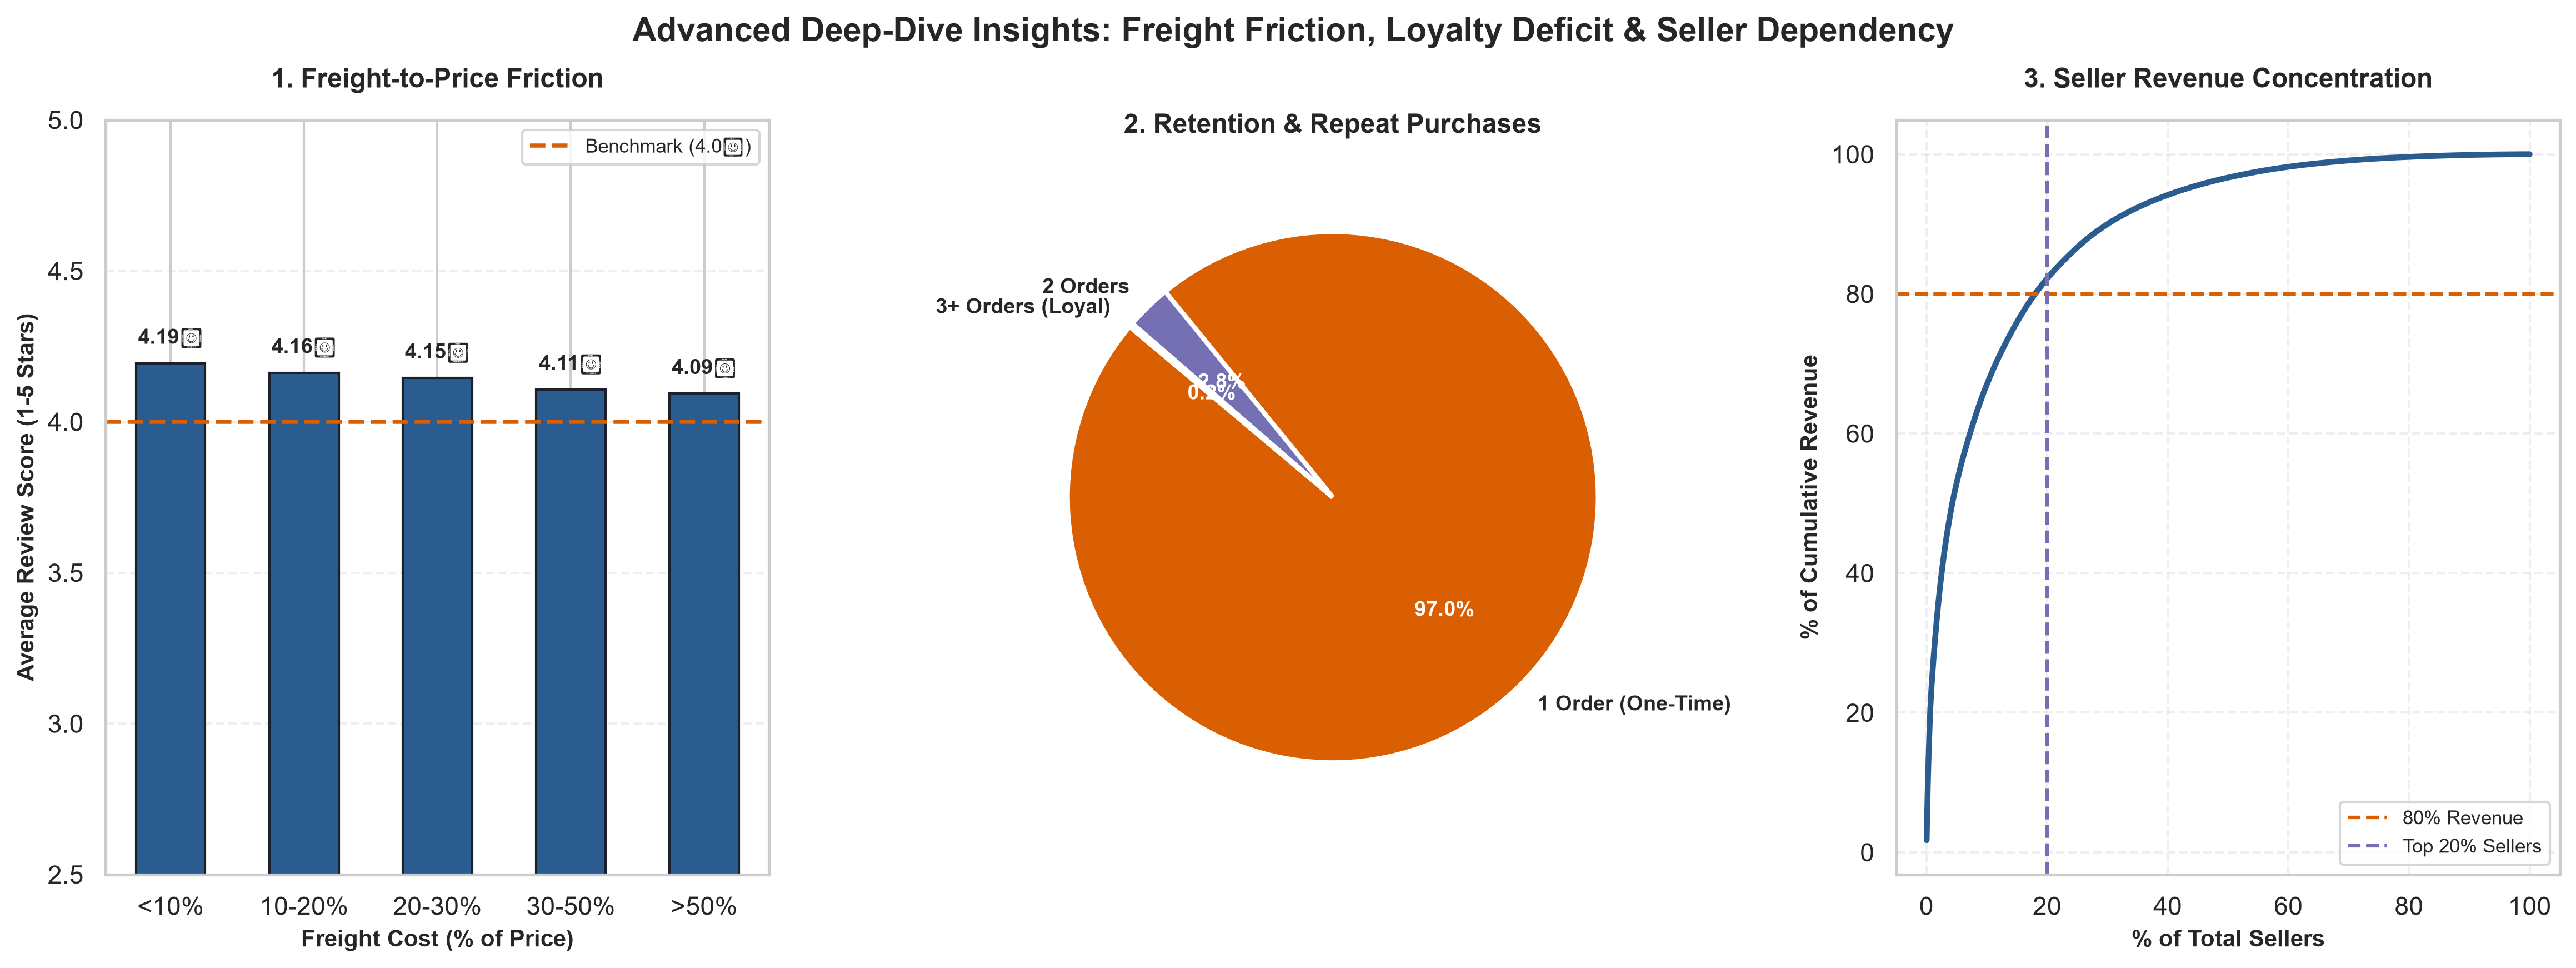

In [15]:
# ---------------------------------------------------------
# 1. Freight Ratio Impact Data Processing
# ---------------------------------------------------------
df_f = df.copy()
df_f['freight_ratio'] = (df_f['total_freight'] / df_f['total_price']) * 100
df_f['freight_ratio_bin'] = pd.cut(
    df_f['freight_ratio'],
    bins=[-1, 10, 20, 30, 50, 1000],
    labels=['<10%', '10-20%', '20-30%', '30-50%', '>50%'],
)

fr_grp = (
    df_f.groupby('freight_ratio_bin', observed=False)
    .agg(
        avg_rating=('review_score', 'mean'),
        total_orders=('order_id', 'count'),
    )
    .reset_index()
)

# ---------------------------------------------------------
# 2. Repeat Purchase Rate Data Processing
# ---------------------------------------------------------
cust_orders = df.groupby('customer_unique_id')['order_id'].nunique()
repeat_counts = pd.Series(
    {
        '1 Order (One-Time)': (cust_orders == 1).sum(),
        '2 Orders': (cust_orders == 2).sum(),
        '3+ Orders (Loyal)': (cust_orders >= 3).sum(),
    }
)

# ---------------------------------------------------------
# 3. Seller Pareto Data Processing
# ---------------------------------------------------------
seller_rev = (
    df.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
seller_rev['cum_perc'] = (
    seller_rev['total_price'].cumsum() / seller_rev['total_price'].sum()
) * 100
seller_rev['seller_perc'] = (
    (seller_rev.index + 1) / len(seller_rev)
) * 100

# ---------------------------------------------------------
# Setup 3-Panel Deep Insight Canvas Layout
# ---------------------------------------------------------
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3, figsize=(19, 6.2), dpi=300, gridspec_kw={'wspace': 0.35}
)

# Panel 1: Freight-to-Price Friction
bars1 = ax1.bar(
    fr_grp['freight_ratio_bin'],
    fr_grp['avg_rating'],
    color='#2B5C8F',
    edgecolor='#1A202C',
    width=0.52,
)
ax1.axhline(
    4.0,
    color='#D95F02',
    linestyle='--',
    linewidth=1.8,
    label='Benchmark (4.0★)',
)
ax1.set_title(
    '1. Freight-to-Price Friction', fontsize=11.5, weight='bold', pad=14
)
ax1.set_xlabel('Freight Cost (% of Price)', fontsize=10, weight='bold')
ax1.set_ylabel('Average Review Score (1-5 Stars)', fontsize=10, weight='bold')
ax1.set_ylim(2.5, 5.0)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')
ax1.legend(loc='upper right', frameon=True, fontsize=8.5)

for bar in bars1:
    yval = bar.get_height()
    if not np.isnan(yval):
        ax1.text(
            bar.get_x() + bar.get_width() / 2.0,
            yval + 0.05,
            f'{yval:.2f}★',
            ha='center',
            va='bottom',
            fontsize=9,
            weight='bold',
        )

# Panel 2: Repeat Purchase Share
colors_rep = ['#D95F02', '#7570B3', '#1B9E77']
wedges, texts, autotexts = ax2.pie(
    repeat_counts,
    labels=repeat_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_rep,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 9, 'weight': 'bold'},
)
for autotext in autotexts:
    autotext.set_color('white')
ax2.set_title(
    '2. Retention & Repeat Purchases', fontsize=11.5, weight='bold', pad=14
)

# Panel 3: Seller Pareto Curve (80/20 Rule)
ax3.plot(
    seller_rev['seller_perc'],
    seller_rev['cum_perc'],
    color='#2B5C8F',
    linewidth=2.5,
)
ax3.axhline(
    80, color='#D95F02', linestyle='--', linewidth=1.5, label='80% Revenue'
)
ax3.axvline(
    20, color='#7570B3', linestyle='--', linewidth=1.5, label='Top 20% Sellers'
)
ax3.set_title(
    '3. Seller Revenue Concentration', fontsize=11.5, weight='bold', pad=14
)
ax3.set_xlabel('% of Total Sellers', fontsize=10, weight='bold')
ax3.set_ylabel('% of Cumulative Revenue', fontsize=10, weight='bold')
ax3.grid(True, linestyle='--', alpha=0.3)
ax3.legend(loc='lower right', frameon=True, fontsize=8.5)

# Master Title
plt.suptitle(
    'Advanced Deep-Dive Insights: Freight Friction, Loyalty Deficit & Seller Dependency',
    fontsize=14.5,
    weight='bold',
    y=0.98,
)

plt.subplots_adjust(bottom=0.15, top=0.88)
plt.show()

## Customer Retention & Repeat Purchase Gap

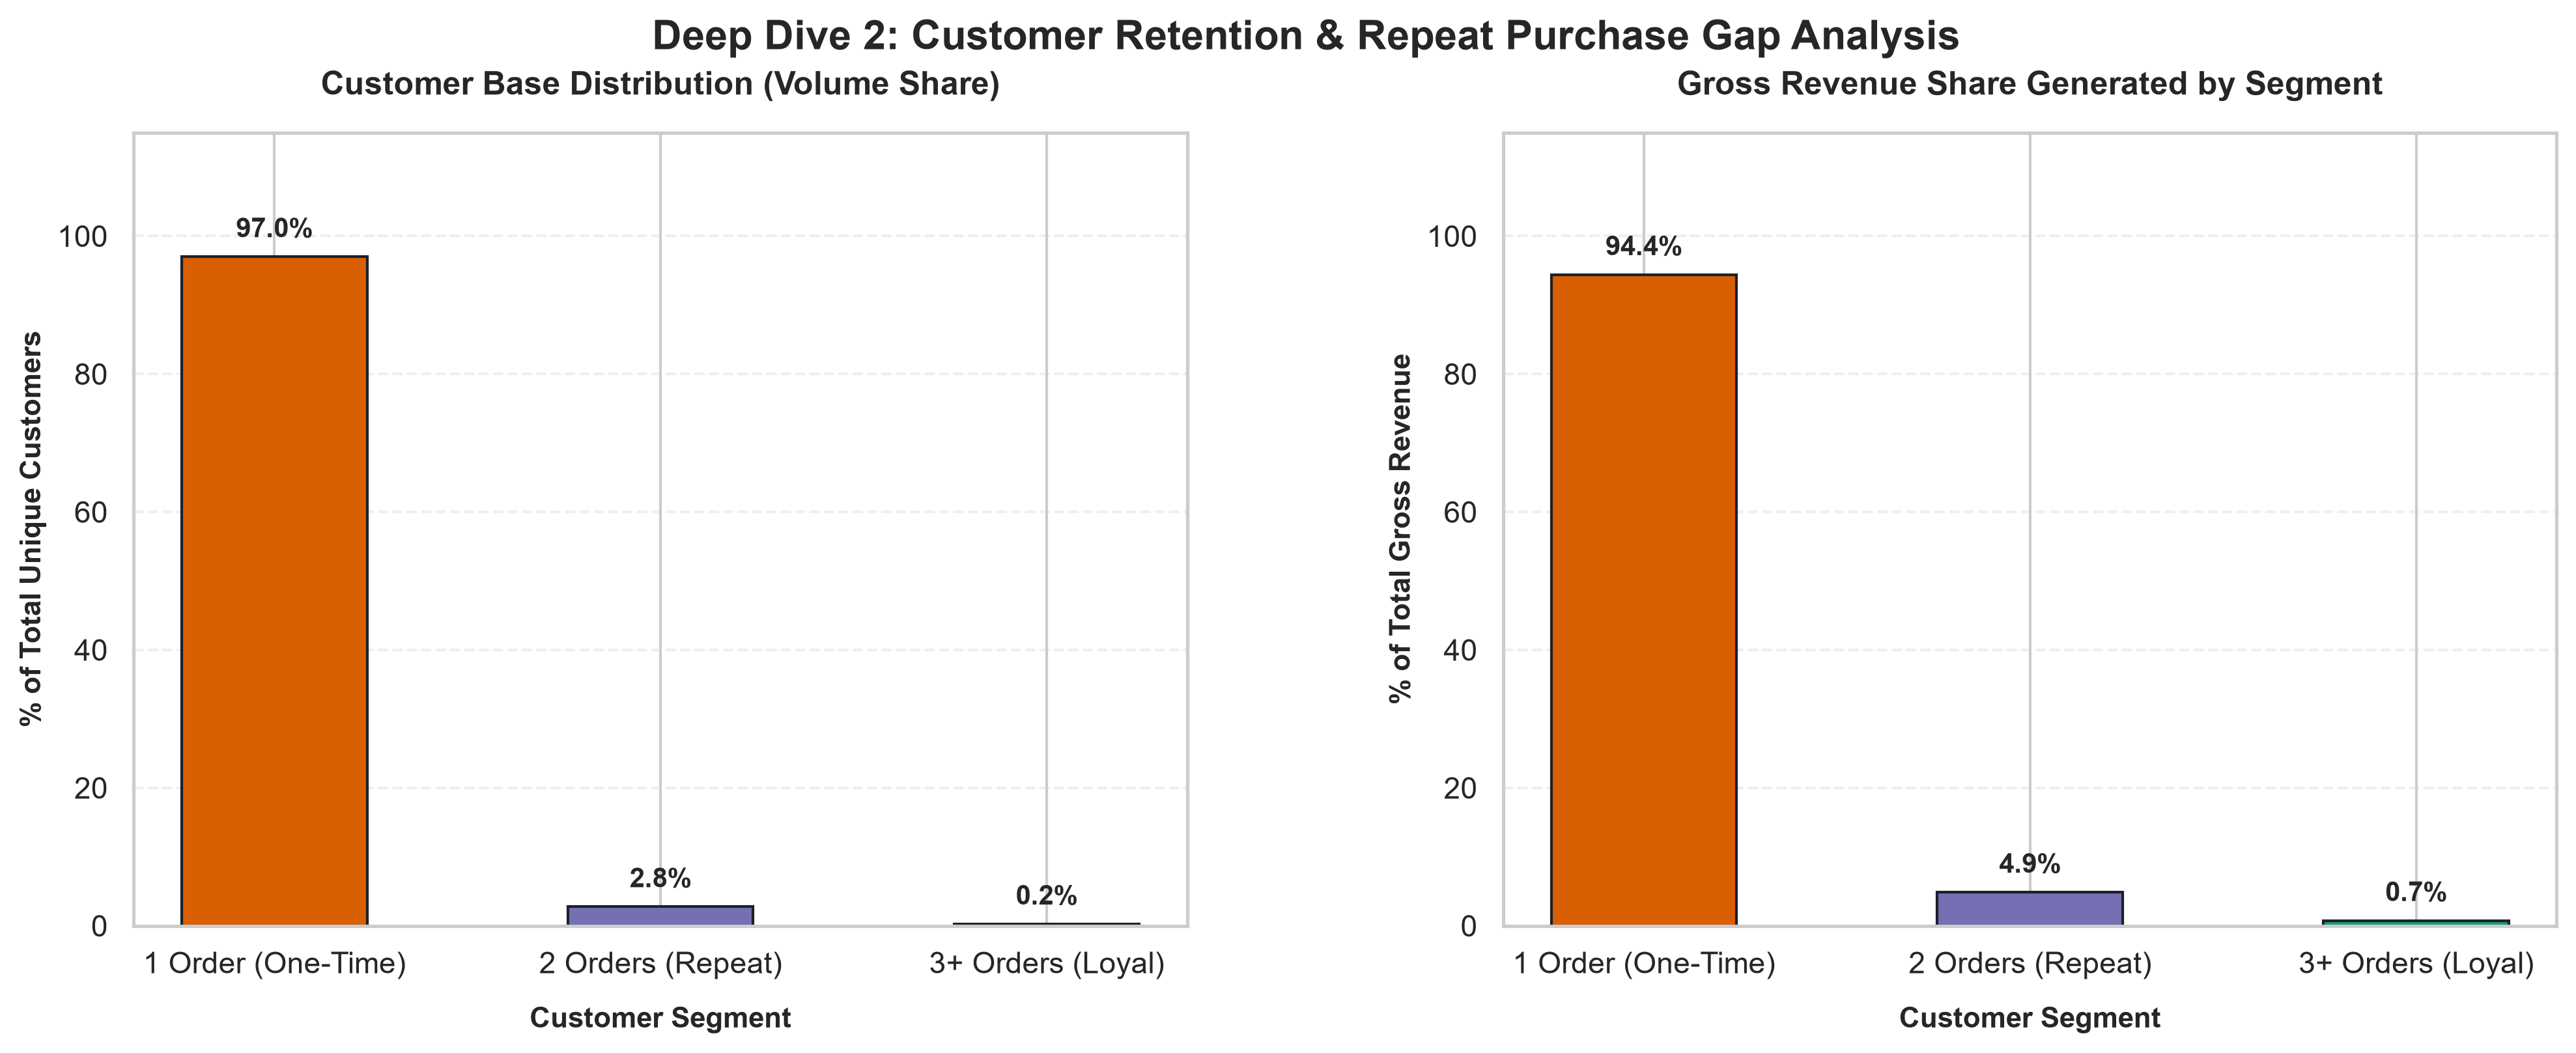

In [16]:
# 1. Customer Level Aggregation
cust_agg = (
    df.groupby('customer_unique_id')
    .agg(
        total_orders=('order_id', 'nunique'),
        total_spent=('total_payment_value', 'sum'),
    )
    .reset_index()
)

# Segment Customers by Order Frequency
def segment_customer(orders):
    if orders == 1:
        return '1 Order (One-Time)'
    elif orders == 2:
        return '2 Orders (Repeat)'
    else:
        return '3+ Orders (Loyal)'


cust_agg['retention_segment'] = cust_agg['total_orders'].apply(segment_customer)

# Revenue and Volume Aggregation
retention_summary = (
    cust_agg.groupby('retention_segment')
    .agg(
        customer_count=('customer_unique_id', 'count'),
        total_revenue=('total_spent', 'sum'),
    )
    .reindex(['1 Order (One-Time)', '2 Orders (Repeat)', '3+ Orders (Loyal)'])
    .reset_index()
)

retention_summary['customer_share'] = (
    retention_summary['customer_count']
    / retention_summary['customer_count'].sum()
) * 100
retention_summary['revenue_share'] = (
    retention_summary['total_revenue'] / retention_summary['total_revenue'].sum()
) * 100

# 2. Setup 2-Panel Executive Visualization Canvas
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 5.8), dpi=300, gridspec_kw={'wspace': 0.30}
)

colors_ret = ['#D95F02', '#7570B3', '#1B9E77']

# Panel 1: Customer Share (%) by Segment
bars1 = ax1.bar(
    retention_summary['retention_segment'],
    retention_summary['customer_share'],
    color=colors_ret,
    edgecolor='#1A202C',
    width=0.48,
)
ax1.set_title(
    'Customer Base Distribution (Volume Share)',
    fontsize=12,
    weight='bold',
    pad=14,
)
ax1.set_xlabel('Customer Segment', fontsize=10.5, weight='bold', labelpad=10)
ax1.set_ylabel('% of Total Unique Customers', fontsize=10.5, weight='bold')
ax1.set_ylim(0, 115)
ax1.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars1:
    yval = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 2.0,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
    )

# Panel 2: Total Revenue Share (%) Generated by Segment
bars2 = ax2.bar(
    retention_summary['retention_segment'],
    retention_summary['revenue_share'],
    color=colors_ret,
    edgecolor='#1A202C',
    width=0.48,
)
ax2.set_title(
    'Gross Revenue Share Generated by Segment',
    fontsize=12,
    weight='bold',
    pad=14,
)
ax2.set_xlabel('Customer Segment', fontsize=10.5, weight='bold', labelpad=10)
ax2.set_ylabel('% of Total Gross Revenue', fontsize=10.5, weight='bold')
ax2.set_ylim(0, 115)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 2.0,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
    )

# Master Title
plt.suptitle(
    'Deep Dive 2: Customer Retention & Repeat Purchase Gap Analysis',
    fontsize=15,
    weight='bold',
    y=0.98,
)

plt.subplots_adjust(bottom=0.18, top=0.88)
plt.show()

### Customer Retention & Repeat Purchase Gap Analysis

* **Severe One-Time Buyer Reliance:** Approximately **97.0% of unique customers are single-order buyers**, generating **94.4% of total revenue**. This indicates that the marketplace relies heavily on continuous new customer acquisition rather than repeat purchases.

* **Low Customer Lifetime Value (LTV):** Repeat buyers account for only a small portion of the customer base, with **2-order customers representing 2.8%** and **3+ order customers representing just 0.2%**. Combined, these repeat customers contribute only **5.6% of total revenue**, highlighting a significant weakness in post-purchase customer re-engagement.

### Strategic Recommendations

* **Automated Re-engagement:** Implement automated post-delivery **email and SMS workflows** with personalized, category-based discount coupons to encourage customers to make their next purchase.

* **Loyalty Program Integration:** Introduce a multi-tier **reward points system**, such as a **"Spend & Earn"** program, to incentivize repeat purchases and increase long-term customer value.

* **Auto-Replenishment:** Test subscription-based **auto-replenishment models** for frequently purchased consumable categories such as **Health, Personal Care, and Groceries**.


## Seller Concentration & Pareto Dependency

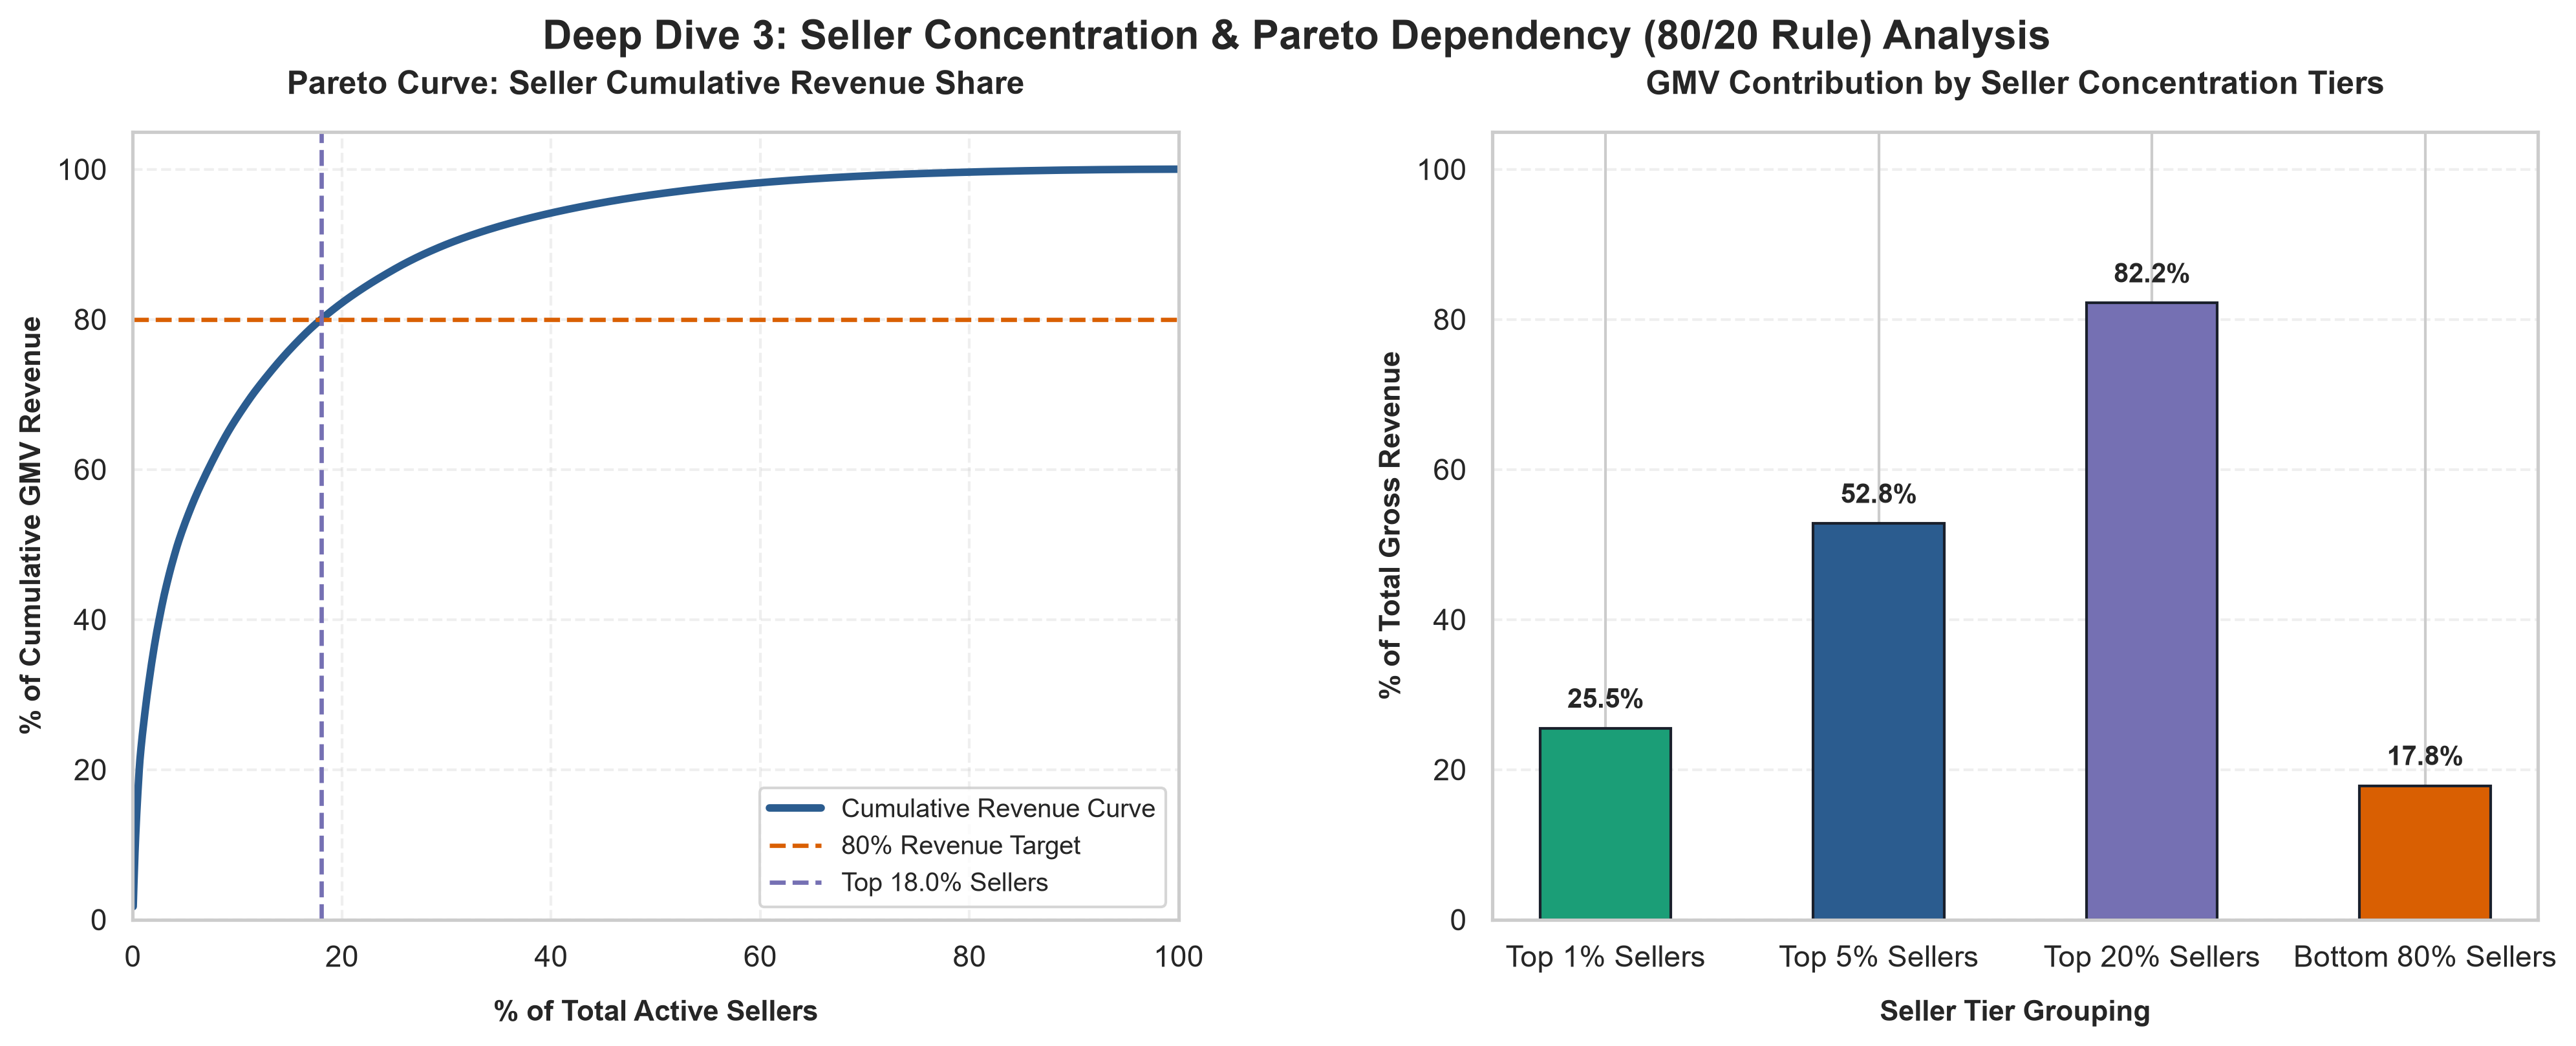

In [17]:
# 1. Seller Level Revenue & Cumulative Aggregation
seller_agg = (
    df.groupby('seller_id')
    .agg(
        total_revenue=('total_price', 'sum'),
        total_orders=('order_id', 'count'),
    )
    .sort_values(by='total_revenue', ascending=False)
    .reset_index()
)

# Cumulative calculations
total_marketplace_rev = seller_agg['total_revenue'].sum()
seller_agg['cum_revenue'] = seller_agg['total_revenue'].cumsum()
seller_agg['cum_rev_perc'] = (
    seller_agg['cum_revenue'] / total_marketplace_rev
) * 100
seller_agg['seller_rank_perc'] = (
    (seller_agg.index + 1) / len(seller_agg)
) * 100

# Calculate exact % of sellers required for 80% GMV
sellers_for_80_perc = (
    (seller_agg['cum_rev_perc'] >= 80).idxmax() + 1
) / len(seller_agg) * 100

# Tiering Sellers for Panel 2
n_sellers = len(seller_agg)
top_1_perc = max(1, int(n_sellers * 0.01))
top_5_perc = max(1, int(n_sellers * 0.05))
top_20_perc = max(1, int(n_sellers * 0.20))

rev_top_1 = (
    seller_agg.iloc[:top_1_perc]['total_revenue'].sum()
    / total_marketplace_rev
) * 100
rev_top_5 = (
    seller_agg.iloc[:top_5_perc]['total_revenue'].sum()
    / total_marketplace_rev
) * 100
rev_top_20 = (
    seller_agg.iloc[:top_20_perc]['total_revenue'].sum()
    / total_marketplace_rev
) * 100
rev_bottom_80 = 100.0 - rev_top_20

tier_df = pd.DataFrame(
    {
        'Seller Tier': [
            'Top 1% Sellers',
            'Top 5% Sellers',
            'Top 20% Sellers',
            'Bottom 80% Sellers',
        ],
        'Revenue Share (%)': [rev_top_1, rev_top_5, rev_top_20, rev_bottom_80],
    }
)

# 2. Setup 2-Panel Executive Visualization Canvas
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 5.8), dpi=300, gridspec_kw={'wspace': 0.30}
)

# Panel 1: Pareto Lorenz Curve
ax1.plot(
    seller_agg['seller_rank_perc'],
    seller_agg['cum_rev_perc'],
    color='#2B5C8F',
    linewidth=2.8,
    label='Cumulative Revenue Curve',
)
ax1.axhline(
    80, color='#D95F02', linestyle='--', linewidth=1.6, label='80% Revenue Target'
)
ax1.axvline(
    sellers_for_80_perc,
    color='#7570B3',
    linestyle='--',
    linewidth=1.6,
    label=f'Top {sellers_for_80_perc:.1f}% Sellers',
)

ax1.set_title(
    'Pareto Curve: Seller Cumulative Revenue Share',
    fontsize=12,
    weight='bold',
    pad=14,
)
ax1.set_xlabel('% of Total Active Sellers', fontsize=10.5, weight='bold', labelpad=10)
ax1.set_ylabel('% of Cumulative GMV Revenue', fontsize=10.5, weight='bold')
ax1.set_xlim(0, 100)
ax1.set_ylim(0, 105)
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='lower right', frameon=True, fontsize=9.5)

# Panel 2: Revenue Distribution by Seller Tier
tier_colors = ['#1B9E77', '#2B5C8F', '#7570B3', '#D95F02']
bars2 = ax2.bar(
    tier_df['Seller Tier'],
    tier_df['Revenue Share (%)'],
    color=tier_colors,
    edgecolor='#1A202C',
    width=0.48,
)
ax2.set_title(
    'GMV Contribution by Seller Concentration Tiers',
    fontsize=12,
    weight='bold',
    pad=14,
)
ax2.set_xlabel('Seller Tier Grouping', fontsize=10.5, weight='bold', labelpad=10)
ax2.set_ylabel('% of Total Gross Revenue', fontsize=10.5, weight='bold')
ax2.set_ylim(0, 105)
ax2.grid(True, linestyle='--', alpha=0.3, axis='y')

for bar in bars2:
    yval = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 2.0,
        f'{yval:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        weight='bold',
    )

# Master Title
plt.suptitle(
    'Deep Dive 3: Seller Concentration & Pareto Dependency (80/20 Rule) Analysis',
    fontsize=15,
    weight='bold',
    y=0.98,
)

plt.subplots_adjust(bottom=0.18, top=0.88)
plt.show()

### **3. Seller Concentration & Pareto Dependency (80/20 Rule) Analysis**

* **Exact Pareto Threshold:** The data shows that the **top 18.0% of sellers generate 80% of total revenue**, closely validating the standard **80/20 Pareto distribution**.

* **Top-Tier Concentration:** The **top 1% of sellers alone contribute 25.5% of total GMV**, while the **top 5% of sellers control 52.8% of the overall revenue volume**.

* **Bottom 80% Tail Vulnerability:** The remaining **bottom 80% of sellers collectively generate only 17.8% of total revenue**, highlighting significant **long-tail inefficiency and revenue concentration** within the seller ecosystem.

---

### **Key Strategic Action Plan for Hackathon Presentation**

1. **VIP Merchant Retention (Top 5%):** Introduce **priority SLAs, dynamic low-commission tiers, and dedicated account management tools** to retain and strengthen relationships with high-value merchants.

2. **Long-Tail Acceleration (Bottom 80%):** Support low-performing sellers through **automated AI listing optimization, keyword recommendations, and initial advertising credits** to improve their visibility and sales performance.

3. **Risk Mitigation:** Develop **merchant diversification algorithms** to reduce dependency on individual sellers and prevent category-level disruptions in case of seller churn.
